<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Facial_Expression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GPU and TensorFlow Check

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs Available:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready and memory growth is enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("GPU not found. Training will run on CPU.")

I0000 00:00:1778396763.671725    1086 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778396765.014885    1086 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778396770.033565    1086 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.21.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready and memory growth is enabled.


Import Libraries

In [ ]:

import os
import json
import time
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from tensorflow.keras.optimizers import Adam, SGD

# Fix random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


Dataset Paths and Basic Setup

In [ ]:
#Define the  paths
train_dir = "facial expression classification-20260415T140837Z-3-001/facial expression classification/train"
validation_dir = "facial expression classification-20260415T140837Z-3-001/facial expression classification/validation"
test_dir = "facial expression classification-20260415T140837Z-3-001/facial expression classification/test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

# Check folders exist
for path in [train_dir, validation_dir, test_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Folder not found: {path}")

CLASS_NAMES = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


Remove Corrupted Images

In [ ]:

def remove_corrupted_images(directory):
    corrupted_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                file_path = os.path.join(root, file)

                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (UnidentifiedImageError, OSError, ValueError):
                    corrupted_files.append(file_path)
                    os.remove(file_path)

    return corrupted_files


all_corrupted = []

for folder in [train_dir, validation_dir, test_dir]:
    corrupted = remove_corrupted_images(folder)
    all_corrupted.extend(corrupted)

print("Total corrupted images removed:", len(all_corrupted))

if len(all_corrupted) > 0:
    print("Removed files:")
    for f in all_corrupted[:20]:
        print(f)
else:
    print("No corrupted images found.")

Total corrupted images removed: 49
Removed files:
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/15395.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/18369.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/26089.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/34380.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/6171.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/8149.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/angry/8887.jpg
facial expression classification-20260415T140837Z-3-001/facial expression classification/train/disgust/10538.jpg
facial expression classification-20260415T140837Z-3-001/facial 

Count Images Per Class

In [ ]:
#Count Images in Train, Validation and Test Sets

def count_images_per_class(directory):
    counts = {}

    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)

        if os.path.exists(cls_path):
            image_files = [
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            counts[cls] = len(image_files)
        else:
            counts[cls] = 0

    return counts


train_counts = count_images_per_class(train_dir)
val_counts = count_images_per_class(validation_dir)
test_counts = count_images_per_class(test_dir)

distribution_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train": [train_counts[c] for c in CLASS_NAMES],
    "Validation": [val_counts[c] for c in CLASS_NAMES],
    "Test": [test_counts[c] for c in CLASS_NAMES]
})

distribution_df["Total"] = (
    distribution_df["Train"] +
    distribution_df["Validation"] +
    distribution_df["Test"]
)

display(distribution_df)

print("Train total:", distribution_df["Train"].sum())
print("Validation total:", distribution_df["Validation"].sum())
print("Test total:", distribution_df["Test"].sum())
print("Total images:", distribution_df["Total"].sum())

,Class,Train,Validation,Test,Total
0,angry,3686,960,300,4946
1,disgust,329,111,100,540
2,fear,3796,1018,300,5114
3,happy,6857,1825,300,8982
4,neutral,4675,1216,300,6191
5,sad,4631,1139,300,6070
6,surprise,2898,797,300,3995


Train total: 26872
Validation total: 7066
Test total: 1900
Total images: 35838


The dataset contains facial expression images divided into training, validation and testing folders. After checking the folders, the total number of images was 35,838. The training set contains 26,872 images, the validation set contains 7,066 images and the test set contains 1,900 images.

The dataset has seven emotion classes: angry, disgust, fear, happy, neutral, sad and surprise. Since the images are already arranged in class folders, the folder names are used as labels by the Keras data generator.

Plot Class Distribution

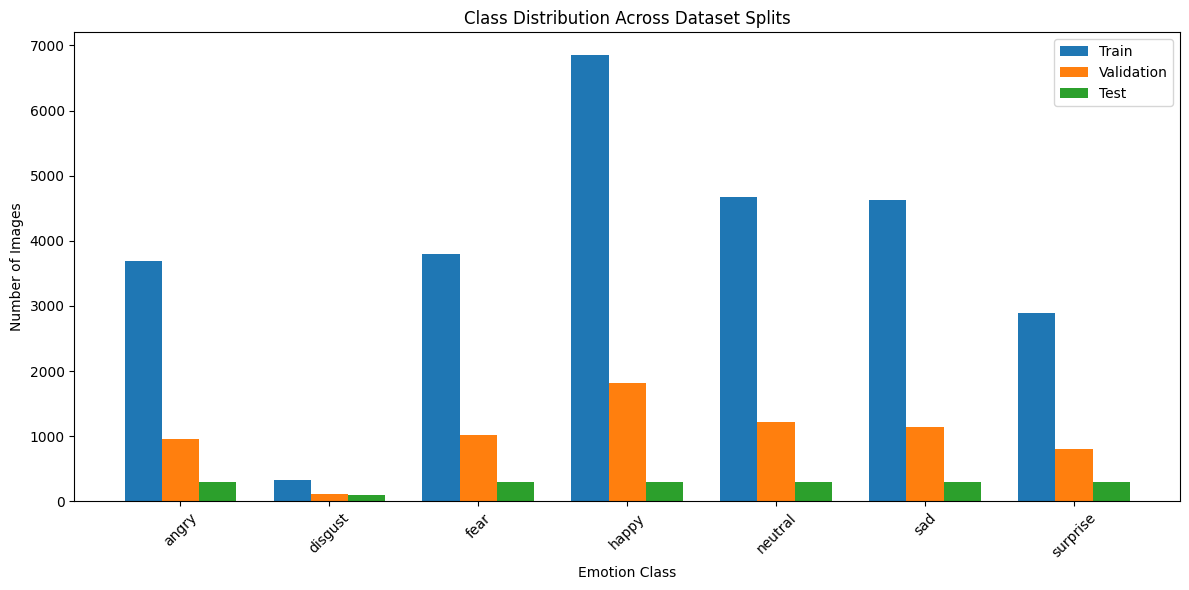

In [ ]:

plt.figure(figsize=(12, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.bar(x - width, distribution_df["Train"], width, label="Train")
plt.bar(x, distribution_df["Validation"], width, label="Validation")
plt.bar(x + width, distribution_df["Test"], width, label="Test")

plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.xticks(x, CLASS_NAMES, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

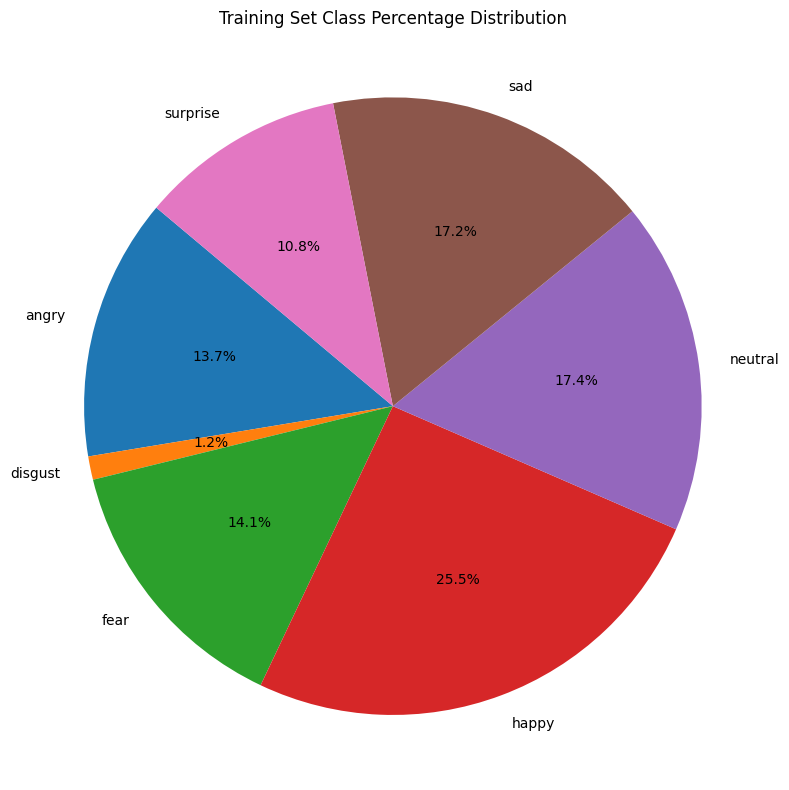

In [ ]:
#Pie Chart for Training Set Class Percentage Distribution

plt.figure(figsize=(8, 8))

plt.pie(
    distribution_df["Train"],
    labels=distribution_df["Class"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Training Set Class Percentage Distribution")
plt.axis("equal")
plt.tight_layout()
plt.show()

Datset Imbalance summary

In [ ]:

for split in ["Train", "Validation", "Test"]:
    max_row = distribution_df.loc[distribution_df[split].idxmax()]
    min_row = distribution_df.loc[distribution_df[split].idxmin()]

    imbalance_ratio = max_row[split] / min_row[split]

    print(f"\n{split} Set Imbalance Summary")
    print("-" * 40)
    print(f"Most frequent class : {max_row['Class']} ({max_row[split]} images)")
    print(f"Least frequent class: {min_row['Class']} ({min_row[split]} images)")
    print(f"Difference          : {max_row[split] - min_row[split]} images")
    print(f"Imbalance ratio     : {imbalance_ratio:.2f}:1")


Train Set Imbalance Summary
----------------------------------------
Most frequent class : happy (6857 images)
Least frequent class: disgust (329 images)
Difference          : 6528 images
Imbalance ratio     : 20.84:1

Validation Set Imbalance Summary
----------------------------------------
Most frequent class : happy (1825 images)
Least frequent class: disgust (111 images)
Difference          : 1714 images
Imbalance ratio     : 16.44:1

Test Set Imbalance Summary
----------------------------------------
Most frequent class : angry (300 images)
Least frequent class: disgust (100 images)
Difference          : 200 images
Imbalance ratio     : 3.00:1


From the class distribution, it can be seen that the dataset is not balanced. The happy class has the highest number of training images, while the disgust class has the lowest number of images. This imbalance can affect the model because the CNN may learn majority classes better than minority classes.

To reduce this issue, balanced data augmentation was applied only on the training set. The validation and test sets were kept unchanged so that the final evaluation remains fair.

Show Sample Images

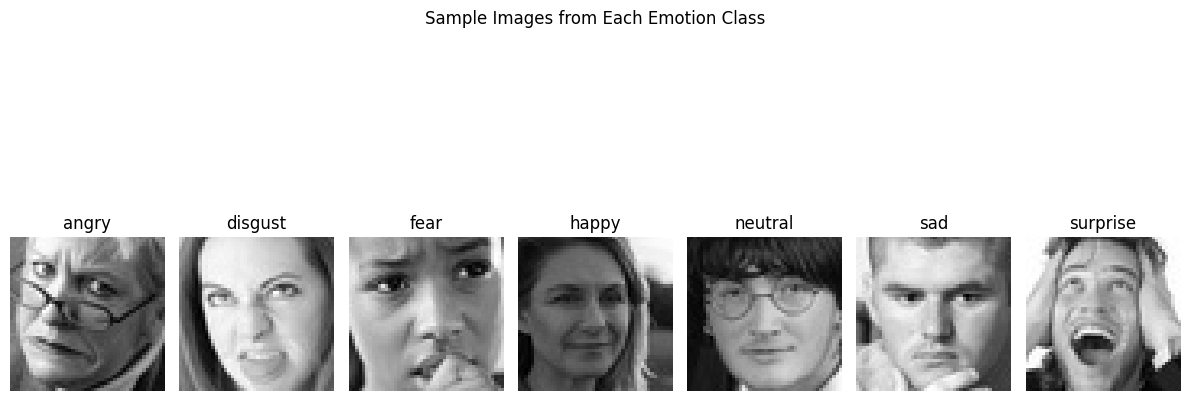

In [ ]:

plt.figure(figsize=(12, 6))

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(train_dir, cls)

    image_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sample_image = random.choice(image_files)
    img_path = os.path.join(cls_path, sample_image)

    img = Image.open(img_path).convert("L")

    plt.subplot(1, NUM_CLASSES, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Images from Each Emotion Class")
plt.tight_layout()
plt.show()

Preview Augmented Images

Found 26872 images belonging to 7 classes.


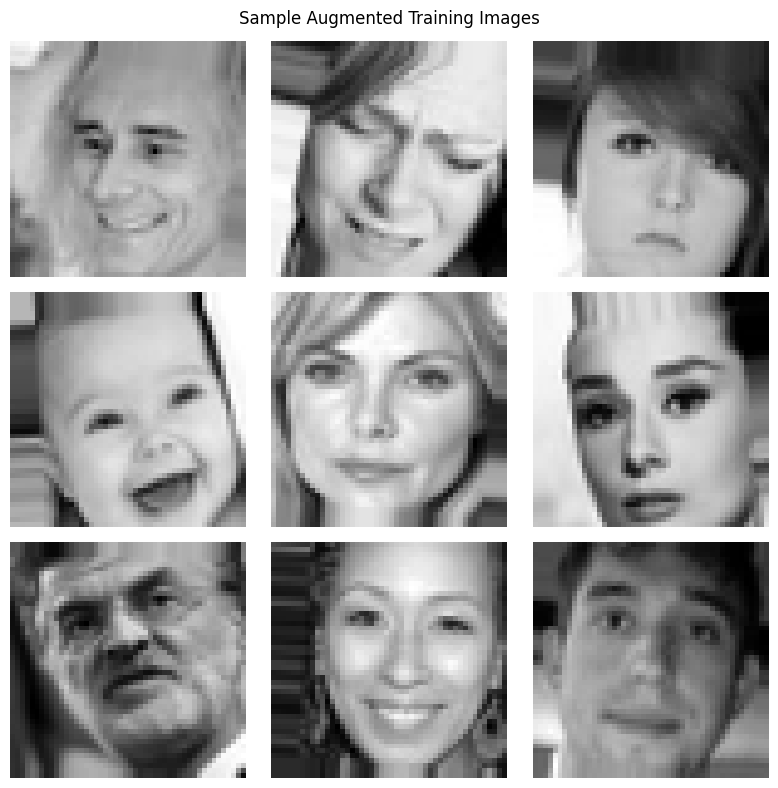

In [ ]:
#Augmented Images

preview_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode="nearest"
)

preview_gen = preview_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=9,
    class_mode=None,
    shuffle=True,
    seed=SEED
)

batch = next(preview_gen)

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

Balanced Data Augmentation

In [ ]:

augmented_train_dir = "augmented_train"

# Delete old augmented folder to avoid duplicate images
if os.path.exists(augmented_train_dir):
    shutil.rmtree(augmented_train_dir)

os.makedirs(augmented_train_dir, exist_ok=True)

# Count current training images dynamically
train_counts = count_images_per_class(train_dir)

print("Original training class counts:")
for cls, count in train_counts.items():
    print(f"{cls:10s}: {count}")

TARGET = max(train_counts.values())
print("\nTarget images per class:", TARGET)

aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode="nearest"
)

for cls in CLASS_NAMES:
    src = os.path.join(train_dir, cls)
    dst = os.path.join(augmented_train_dir, cls)
    os.makedirs(dst, exist_ok=True)

    originals = [
        f for f in os.listdir(src)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    current_count = len(originals)

    # Copy original images first
    for fname in originals:
        img = Image.open(os.path.join(src, fname)).convert("L").resize(IMG_SIZE)
        img.save(os.path.join(dst, fname))

    needed = TARGET - current_count

    if needed <= 0:
        print(f"{cls}: no augmentation needed ({current_count} images)")
        continue

    generated = 0

    while generated < needed:
        fname = random.choice(originals)

        img = Image.open(os.path.join(src, fname)).convert("L").resize(IMG_SIZE)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        for batch in aug.flow(img_array, batch_size=1):
            out_fname = f"aug_{cls}_{generated:05d}.png"
            aug_img = batch[0].squeeze()

            # Keep pixel values valid
            aug_img = np.clip(aug_img, 0, 255).astype("uint8")

            Image.fromarray(aug_img, mode="L").save(os.path.join(dst, out_fname))

            generated += 1
            break

    print(f"{cls}: {current_count} -> {TARGET}, added {needed}")

print("\nBalanced augmentation completed.")

Original training class counts:
angry     : 3686
disgust   : 329
fear      : 3796
happy     : 6857
neutral   : 4675
sad       : 4631
surprise  : 2898

Target images per class: 6857
angry: 3686 -> 6857, added 3171
disgust: 329 -> 6857, added 6528
fear: 3796 -> 6857, added 3061
happy: no augmentation needed (6857 images)
neutral: 4675 -> 6857, added 2182
sad: 4631 -> 6857, added 2226
surprise: 2898 -> 6857, added 3959

Balanced augmentation completed.


Verify Augmented Dataset

,Class,Augmented Train Count
0,angry,6857
1,disgust,6857
2,fear,6857
3,happy,6857
4,neutral,6857
5,sad,6857
6,surprise,6857


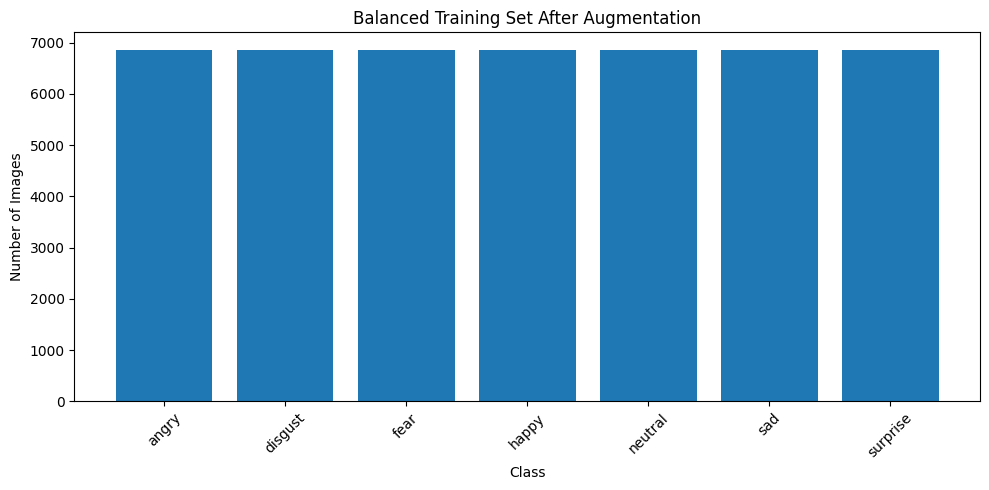

In [ ]:
aug_counts = {}

for cls in CLASS_NAMES:
    cls_path = os.path.join(augmented_train_dir, cls)

    image_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    aug_counts[cls] = len(image_files)

aug_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Augmented Train Count": [aug_counts[c] for c in CLASS_NAMES]
})

display(aug_df)

plt.figure(figsize=(10, 5))
plt.bar(aug_df["Class"], aug_df["Augmented Train Count"])
plt.title("Balanced Training Set After Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Show Augmented Samples Per Class

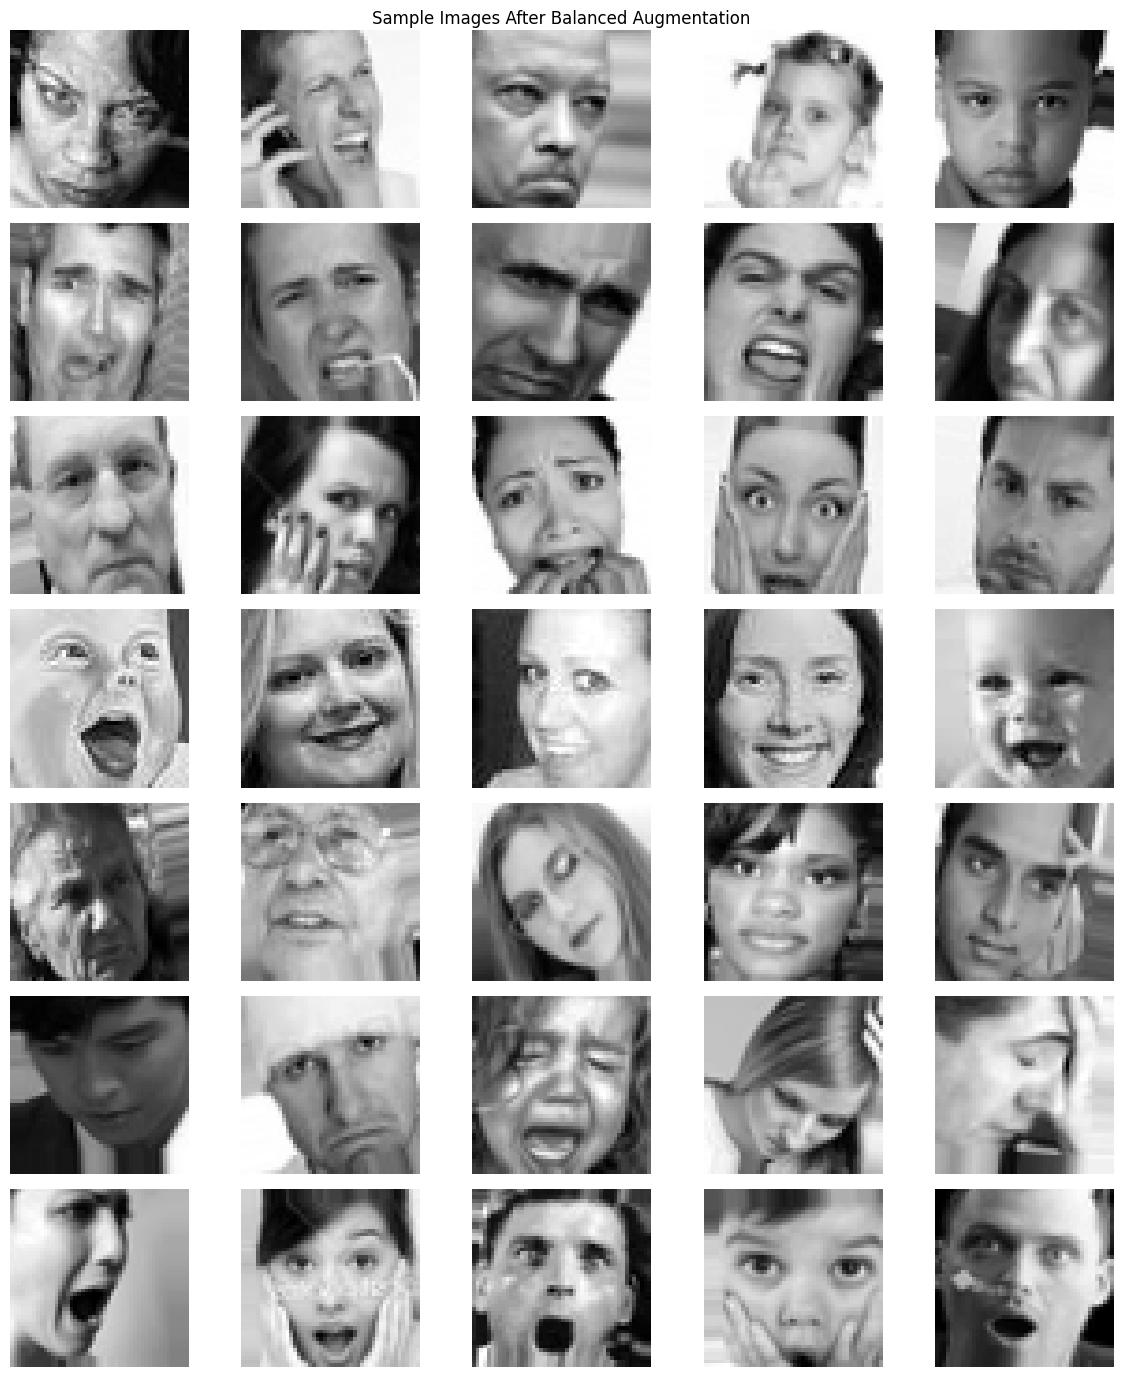

In [ ]:

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, NUM_CLASSES * 2))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(augmented_train_dir, cls)

    aug_imgs = [f for f in os.listdir(cls_path) if f.startswith("aug_")]
    all_imgs = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sample_pool = aug_imgs if len(aug_imgs) > 0 else all_imgs
    samples = random.sample(sample_pool, min(5, len(sample_pool)))

    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname)).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(cls.capitalize(), fontsize=10)

    for col in range(len(samples), 5):
        axes[row, col].axis("off")

plt.suptitle("Sample Images After Balanced Augmentation")
plt.tight_layout()
plt.show()

The augmented images show small transformations such as rotation, shifting, zooming and horizontal flipping. These transformations are useful because they create different variations of the same expression without changing the actual label.

This helps the model generalise better because it learns facial expression patterns instead of memorising exact images.

Data Generators

In [ ]:
# Data Generators for CNN Models
augmented_train_dir = "augmented_train"

print("Augmented train dir exists:", os.path.exists(augmented_train_dir))
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    augmented_train_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Train batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:", len(test_generator))

Augmented train dir exists: True
Found 47999 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train batches: 750
Validation batches: 111
Test batches: 30


The scratch CNN models use grayscale images resized to 48×48 pixels. The pixel values are normalised using rescaling so that all values are between 0 and 1. This makes training more stable and faster.

The training generator uses the balanced augmented training folder, while the validation and test generators use the original validation and test data. This allows the model to learn from balanced data but still be tested on real unseen images.

Result Saving Helper Functions

In [ ]:
#Helper Functions for Saving Best Results

RESULTS_DIR = "model_results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def get_callbacks(model_name, patience=5):
    """
    This function creates callbacks for every model.

    The best model is saved based on validation loss.
    Lower validation loss means the model is generalising better on unseen validation data.
    """
    model_folder = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_folder, exist_ok=True)

    callbacks = [
        ModelCheckpoint(
            filepath=os.path.join(model_folder, f"{model_name}_best.keras"),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        ),

        CSVLogger(
            filename=os.path.join(model_folder, f"{model_name}_training_log.csv"),
            append=False
        ),

        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            mode="min",
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    return callbacks


def save_training_history(history, model_name, training_time):
    """
    Saves the training history and training time of a model.
    """
    model_folder = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_folder, exist_ok=True)

    with open(os.path.join(model_folder, f"{model_name}_history.json"), "w") as f:
        json.dump(history.history, f)

    with open(os.path.join(model_folder, f"{model_name}_training_time.txt"), "w") as f:
        f.write(str(training_time))

    print(f"Saved training history and time for {model_name}")


def plot_and_save_history(history, model_name):
    """
    Plots and saves accuracy and loss curves.

    These curves help to understand model learning behaviour and check overfitting.
    """
    model_folder = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_folder, exist_ok=True)

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy Curve - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_accuracy_curve.png"), dpi=300)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss Curve - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_loss_curve.png"), dpi=300)
    plt.show()


def evaluate_and_save_best_model(model, test_gen, model_name):
    """
    Evaluates the best saved model on the test data.

    It saves:
    - test accuracy and loss
    - classification report
    - confusion matrix
    """
    model_folder = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_folder, exist_ok=True)

    best_model_path = os.path.join(model_folder, f"{model_name}_best.keras")

    # Load the best saved model if it exists
    if os.path.exists(best_model_path):
        print(f"Loading best saved model from: {best_model_path}")
        model = load_model(best_model_path)
    else:
        print("Best saved model was not found. Evaluating the current model instead.")

    test_gen.reset()
    test_loss, test_acc = model.evaluate(test_gen, verbose=1)

    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    class_labels = list(test_gen.class_indices.keys())

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_labels
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        output_dict=True
    )

    print(f"\nModel: {model_name}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(report_text)

    # Save test metrics
    metrics = {
        "model_name": model_name,
        "best_model_selection": "val_loss",
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc)
    }

    with open(os.path.join(model_folder, f"{model_name}_test_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # Save classification report
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(os.path.join(model_folder, f"{model_name}_classification_report.csv"))

    # Save confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_confusion_matrix.png"), dpi=300)
    plt.show()

    return test_acc, test_loss

Models

1. Baseline CNN Model

In [ ]:

def build_baseline_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(48, 48, 1)),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        Dropout(0.5),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(64, activation="relu"),

        Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

I0000 00:00:1778262534.398822    2868 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN contains three convolutional blocks followed by fully connected layers. The convolutional layers extract visual features from facial images, while max-pooling reduces the feature map size and keeps the most important information.

The final softmax layer outputs probabilities for the seven emotion classes. This model is used as the starting point so that the deeper CNN and transfer learning models can be compared against it.

Train Baseline CNN and Save Best

Epoch 1/50


I0000 00:00:1778262590.481125    2868 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778262594.712721    4520 service.cc:153] XLA service 0x76ec64036800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778262594.712795    4520 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778262594.892485    4520 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778262595.664998    4520 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778262595.845093    4520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2732__.47
I0000 00:00:1778262601.663376    4520 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe th

  1/750 ━━━━━━━━━━━━━━━━━━━━ 6:03:40 29s/step - accuracy: 0.1250 - loss: 1.9341

I0000 00:00:1778262619.330453    4520 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


266/750 ━━━━━━━━━━━━━━━━━━━━ 9:20 1s/step - accuracy: 0.1421 - loss: 1.9482

I0000 00:00:1778262928.134075    4518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2732__.47
I0000 00:00:1778262928.896754    4518 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778262930.177206    4518 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778262930.964301    4965 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1778262930.986004    4958 subprocess_compilation.cc:348] ptxas warning : Registers are spilled

750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1568 - loss: 1.9387

I0000 00:00:1778263498.290679    4518 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_loss improved from None to 1.74377, saving model to model_results/baseline_cnn/baseline_cnn_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1090s 1s/step - accuracy: 0.1945 - loss: 1.9011 - val_accuracy: 0.2787 - val_loss: 1.7438 - learning_rate: 0.0010
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3530 - loss: 1.6610
Epoch 2: val_loss improved from 1.74377 to 1.39860, saving model to model_results/baseline_cnn/baseline_cnn_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1013s 1s/step - accuracy: 0.3837 - loss: 1.5947 - val_accuracy: 0.4597 - val_loss: 1.3986 - learning_rate: 0.0010
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4453 - loss: 1.4449
Epoch 3: val_loss improved from 1.39860 to 1.32203, saving model to model_results/baseline_cnn/baseline_cnn_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 358s 478ms/step - accuracy: 0.4562 - loss: 1.4183 - val_accuracy: 0.4909 - val_loss: 1.3220 - learning_rate: 0.0010
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0

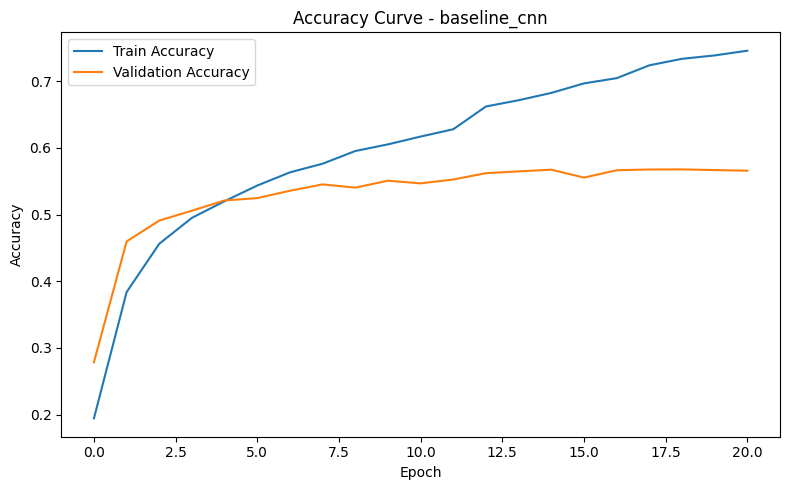

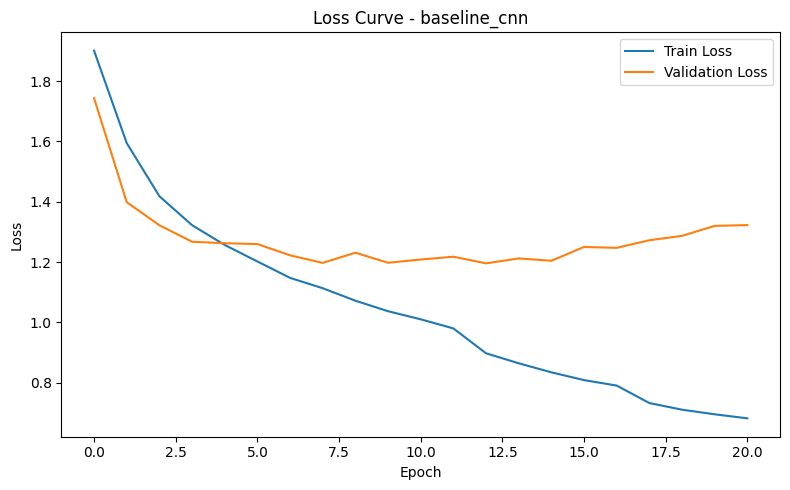

Baseline CNN training time: 10267.34 seconds


In [ ]:

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=get_callbacks("baseline_cnn"),
    verbose=1
)

baseline_train_time = time.time() - start_time

save_training_history(
    history=baseline_history,
    model_name="baseline_cnn",
    training_time=baseline_train_time
)

plot_and_save_history(
    history=baseline_history,
    model_name="baseline_cnn"
)

print(f"Baseline CNN training time: {baseline_train_time:.2f} seconds")

Load and Evaluate Best Baseline CNN

Loading best saved model from: model_results/baseline_cnn/baseline_cnn_best.keras
29/30 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4777 - loss: 1.4431

I0000 00:00:1778272999.477308    4519 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778273000.547807    8796 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 196 bytes spill stores, 196 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5311 - loss: 1.3029
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 623ms/step

Model: baseline_cnn
Test Loss: 1.3029
Test Accuracy: 0.5311

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.44      0.46       300
     disgust       0.60      0.57      0.58       100
        fear       0.46      0.29      0.35       300
       happy       0.65      0.77      0.71       300
     neutral       0.42      0.56      0.48       300
         sad       0.40      0.38      0.39       300
    surprise       0.70      0.74      0.72       300

    accuracy                           0.53      1900
   macro avg       0.53      0.53      0.53      1900
weighted avg       0.53      0.53      0.52      1900



<Figure size 800x600 with 0 Axes>

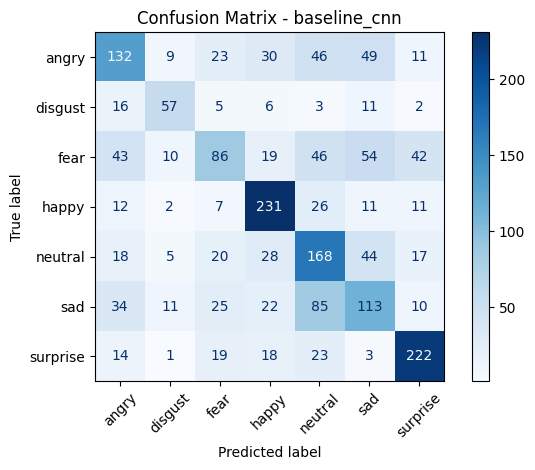

In [ ]:

best_baseline_model = load_model("model_results/baseline_cnn/baseline_cnn_best.keras")

baseline_best_acc, baseline_best_loss = evaluate_and_save_best_model(
    model=best_baseline_model,
    test_gen=test_generator,
    model_name="baseline_cnn"
)

The baseline CNN achieved 53.11% test accuracy and 0.52 weighted F1-score. This shows that the model was able to learn useful facial expression features, but the performance was still limited.

Some emotions are easier to classify, such as happy and surprise, because they have stronger visual differences. However, emotions such as fear, sad and neutral are more difficult because their facial expressions can look similar.

Deeper CNN Model

In [ ]:
# Build Deeper CNN Model with Batch Normalization and Dropout

def build_deeper_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(48, 48, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(256, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        Flatten(),

        Dense(512, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


deeper_model = build_deeper_model()

deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,932,775 (7.37 MB)

 Trainable params: 1,929,831 (7.36 MB)

 Non-trainable params: 2,944 (11.50 KB)

Train Deeper CNN with Adam and Save Best

Epoch 1/35


I0000 00:00:1778273819.062588    4517 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87590__.116


286/750 ━━━━━━━━━━━━━━━━━━━━ 8:02 1s/step - accuracy: 0.1728 - loss: 2.4255

I0000 00:00:1778274151.091932    4520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87590__.116


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1923 - loss: 2.2290
Epoch 1: val_loss improved from None to 1.98955, saving model to model_results/deeper_cnn_adam/deeper_cnn_adam_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1141s 1s/step - accuracy: 0.2312 - loss: 2.0072 - val_accuracy: 0.2158 - val_loss: 1.9896 - learning_rate: 0.0010
Epoch 2/35
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.3754 - loss: 1.6241
Epoch 2: val_loss improved from 1.98955 to 1.35586, saving model to model_results/deeper_cnn_adam/deeper_cnn_adam_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 879s 1s/step - accuracy: 0.4079 - loss: 1.5487 - val_accuracy: 0.4805 - val_loss: 1.3559 - learning_rate: 0.0010
Epoch 3/35
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.4744 - loss: 1.3850
Epoch 3: val_loss did not improve from 1.35586
750/750 ━━━━━━━━━━━━━━━━━━━━ 556s 741ms/step - accuracy: 0.4851 - loss: 1.3567 - val_accuracy: 0.4522 - val_loss: 1.3942 - learning_rate: 0.0010
Epoch 4/35
750/750 ━━━━━━━

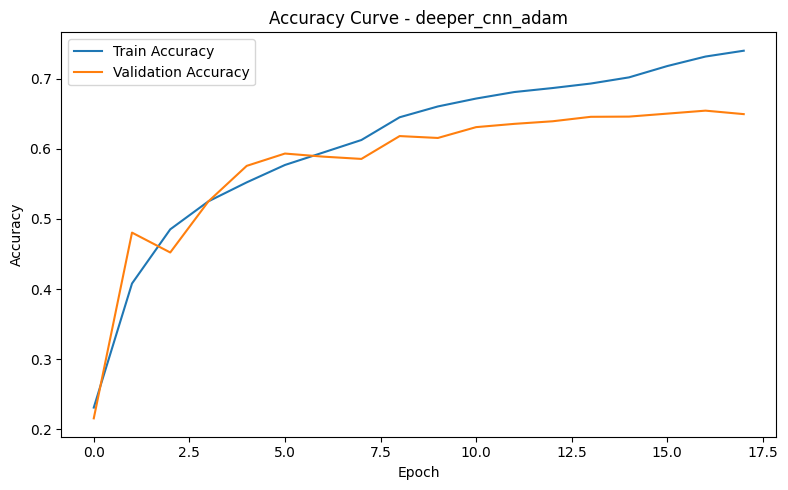

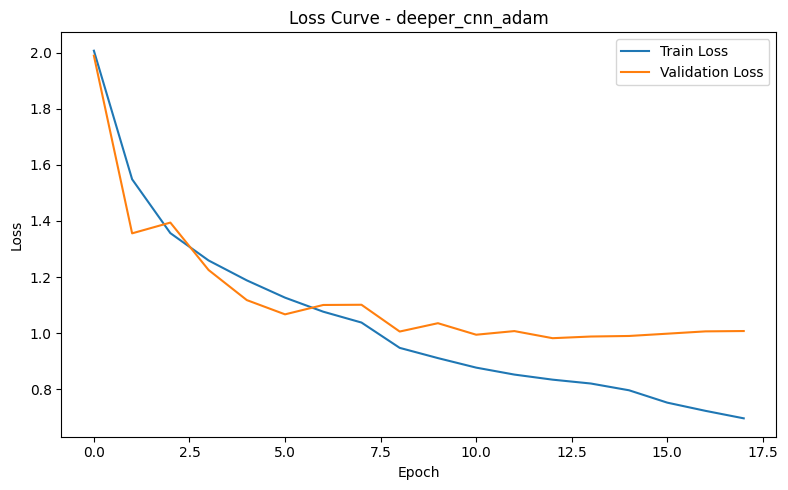

Deeper CNN Adam training time: 7930.97 seconds


In [ ]:
# Train Deeper CNN with Adam and Save Best Result

start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    callbacks=get_callbacks("deeper_cnn_adam"),
    verbose=1
)

deeper_train_time = time.time() - start_time

save_training_history(
    history=deeper_history,
    model_name="deeper_cnn_adam",
    training_time=deeper_train_time
)

plot_and_save_history(
    history=deeper_history,
    model_name="deeper_cnn_adam"
)

print(f"Deeper CNN Adam training time: {deeper_train_time:.2f} seconds")

Load and Evaluate Best Deeper CNN Adam

Loading best saved model from: model_results/deeper_cnn_adam/deeper_cnn_adam_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5874 - loss: 1.1022
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 443ms/step

Model: deeper_cnn_adam
Test Loss: 1.1022
Test Accuracy: 0.5874

Classification Report:
              precision    recall  f1-score   support

       angry       0.58      0.51      0.55       300
     disgust       0.78      0.64      0.70       100
        fear       0.51      0.35      0.42       300
       happy       0.77      0.76      0.76       300
     neutral       0.45      0.68      0.54       300
         sad       0.45      0.45      0.45       300
    surprise       0.75      0.76      0.76       300

    accuracy                           0.59      1900
   macro avg       0.61      0.59      0.60      1900
weighted avg       0.60      0.59      0.58      1900



<Figure size 800x600 with 0 Axes>

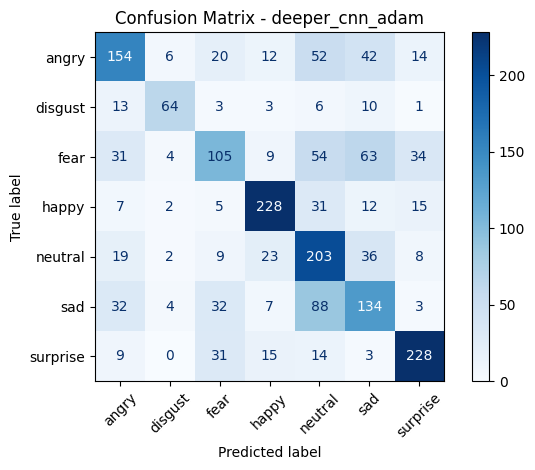

In [ ]:
# Load and Evaluate Best Deeper CNN Adam Model

best_deeper_adam_model = load_model("model_results/deeper_cnn_adam/deeper_cnn_adam_best.keras")

deeper_adam_best_acc, deeper_adam_best_loss = evaluate_and_save_best_model(
    model=best_deeper_adam_model,
    test_gen=test_generator,
    model_name="deeper_cnn_adam"
)

The deeper CNN trained with Adam achieved better performance than the baseline model. It reached 58.74% test accuracy and 0.58 weighted F1-score. This shows that increasing the model depth and adding Batch Normalization and Dropout helped the model learn stronger facial features.

Adam helped the model converge faster, but it was not the best final model in this experiment.

Train Deeper CNN with SGD and Save Best

Epoch 1/35


I0000 00:00:1778283111.209053    4519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170691__.116


504/750 ━━━━━━━━━━━━━━━━━━━━ 3:28 846ms/step - accuracy: 0.1638 - loss: 2.1878

I0000 00:00:1778283557.448446    4519 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_170691__.116


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.1678 - loss: 2.1302
Epoch 1: val_loss improved from None to 1.92270, saving model to model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 867s 1s/step - accuracy: 0.1790 - loss: 1.9996 - val_accuracy: 0.1997 - val_loss: 1.9227 - learning_rate: 0.0100
Epoch 2/35
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.2009 - loss: 1.9309
Epoch 2: val_loss improved from 1.92270 to 1.80454, saving model to model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 670s 892ms/step - accuracy: 0.2069 - loss: 1.9197 - val_accuracy: 0.2763 - val_loss: 1.8045 - learning_rate: 0.0100
Epoch 3/35
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.2368 - loss: 1.8750
Epoch 3: val_loss improved from 1.80454 to 1.73678, saving model to model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 290s 386ms/step - accuracy: 0.2472 - loss: 1.8586 - val_accuracy:

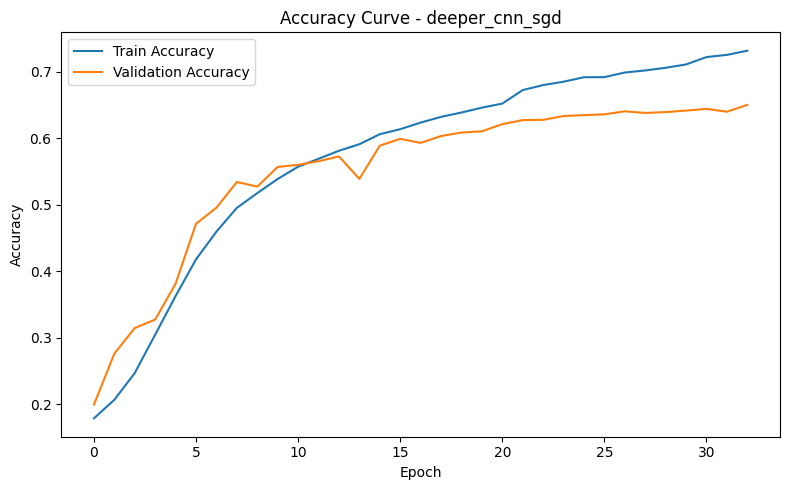

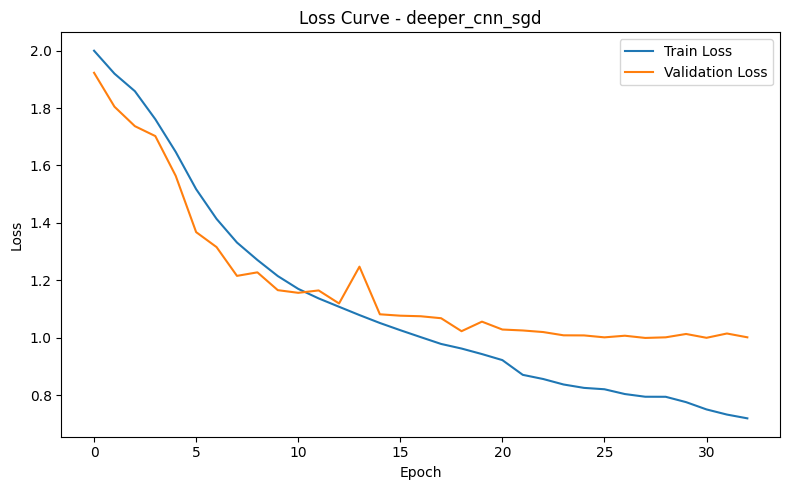

Deeper CNN SGD training time: 15083.45 seconds


In [ ]:

sgd_model = build_deeper_model()

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

sgd_history = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    callbacks=get_callbacks("deeper_cnn_sgd"),
    verbose=1
)

sgd_train_time = time.time() - start_time

save_training_history(
    history=sgd_history,
    model_name="deeper_cnn_sgd",
    training_time=sgd_train_time
)

plot_and_save_history(
    history=sgd_history,
    model_name="deeper_cnn_sgd"
)

print(f"Deeper CNN SGD training time: {sgd_train_time:.2f} seconds")

Load and Evaluate Best Deeper CNN SGD

Loading best saved model from: model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6147 - loss: 1.1115
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 775ms/step

Model: deeper_cnn_sgd
Test Loss: 1.1115
Test Accuracy: 0.6147

Classification Report:
              precision    recall  f1-score   support

       angry       0.58      0.54      0.56       300
     disgust       0.82      0.60      0.69       100
        fear       0.54      0.38      0.45       300
       happy       0.77      0.77      0.77       300
     neutral       0.51      0.68      0.58       300
         sad       0.49      0.53      0.51       300
    surprise       0.76      0.79      0.77       300

    accuracy                           0.61      1900
   macro avg       0.64      0.61      0.62      1900
weighted avg       0.62      0.61      0.61      1900



<Figure size 800x600 with 0 Axes>

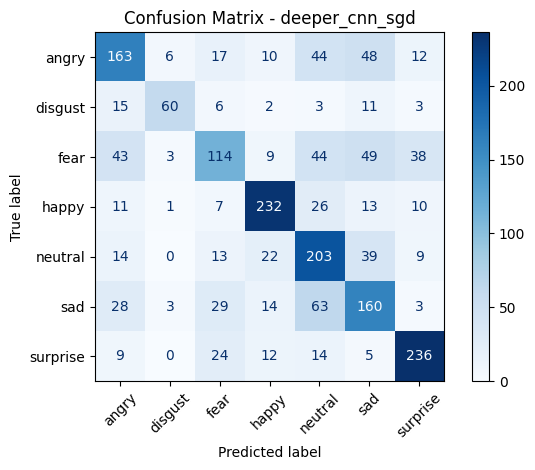

In [ ]:

best_sgd_model = load_model("model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras")

sgd_best_acc, sgd_best_loss = evaluate_and_save_best_model(
    model=best_sgd_model,
    test_gen=test_generator,
    model_name="deeper_cnn_sgd"
)

The deeper CNN trained with SGD achieved the best result in this notebook. It reached 61.47% test accuracy and 0.61 weighted F1-score. Although SGD took more training time than Adam, it gave better generalisation on the test set.

Therefore, the Deeper CNN with SGD is selected as the best scratch CNN model.

Ablation Model Without Batch Normalization

In [ ]:
def build_ablation_no_bn():
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(48, 48, 1)),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(256, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        Flatten(),

        Dense(512, activation="relu"),
        Dropout(0.5),

        Dense(256, activation="relu"),
        Dropout(0.4),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


ablation_model = build_ablation_no_bn()

ablation_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ablation_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,887 (7.35 MB)

 Trainable params: 1,926,887 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

Train Ablation Model and Save Best

Epoch 1/30
472/750 ━━━━━━━━━━━━━━━━━━━━ 6:07 1s/step - accuracy: 0.1434 - loss: 1.9468

I0000 00:00:1778299886.518183    4520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_301376__.64


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1430 - loss: 1.9467
Epoch 1: val_loss improved from None to 1.94773, saving model to model_results/ablation_no_batchnorm/ablation_no_batchnorm_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1246s 2s/step - accuracy: 0.1426 - loss: 1.9465 - val_accuracy: 0.1441 - val_loss: 1.9477 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.1437 - loss: 1.9461
Epoch 2: val_loss did not improve from 1.94773
750/750 ━━━━━━━━━━━━━━━━━━━━ 452s 602ms/step - accuracy: 0.1445 - loss: 1.9460 - val_accuracy: 0.1441 - val_loss: 1.9498 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.1432 - loss: 1.9461
Epoch 3: val_loss improved from 1.94773 to 1.94489, saving model to model_results/ablation_no_batchnorm/ablation_no_batchnorm_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 284s 379ms/step - accuracy: 0.1419 - loss: 1.9461 - val_accuracy: 0.2583 - val_loss: 1.9449 - learning_rate: 0.0010

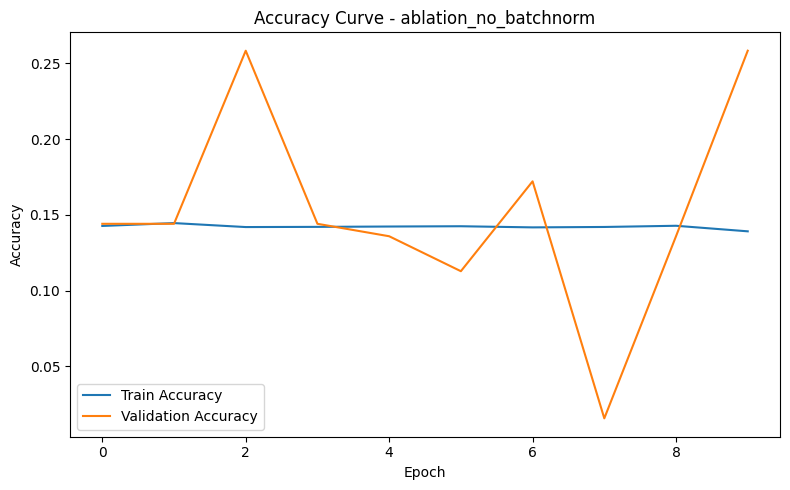

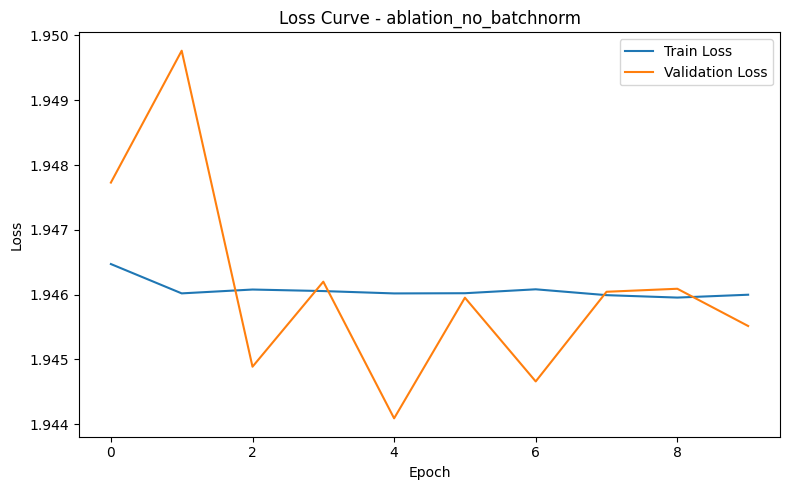

Ablation model training time: 4262.99 seconds


In [ ]:
start_time = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=get_callbacks("ablation_no_batchnorm"),
    verbose=1
)

ablation_train_time = time.time() - start_time

save_training_history(
    history=ablation_history,
    model_name="ablation_no_batchnorm",
    training_time=ablation_train_time
)

plot_and_save_history(
    history=ablation_history,
    model_name="ablation_no_batchnorm"
)

print(f"Ablation model training time: {ablation_train_time:.2f} seconds")

Load and Evaluate Best Ablation Model

Loading best saved model from: model_results/ablation_no_batchnorm/ablation_no_batchnorm_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.1579 - loss: 1.9446
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step

Model: ablation_no_batchnorm
Test Loss: 1.9446
Test Accuracy: 0.1579

Classification Report:
              precision    recall  f1-score   support

       angry       0.16      1.00      0.27       300
     disgust       0.00      0.00      0.00       100
        fear       0.00      0.00      0.00       300
       happy       0.00      0.00      0.00       300
     neutral       0.00      0.00      0.00       300
         sad       0.00      0.00      0.00       300
    surprise       0.00      0.00      0.00       300

    accuracy                           0.16      1900
   macro avg       0.02      0.14      0.04      1900
weighted avg       0.02      0.16      0.04      1900



<Figure size 800x600 with 0 Axes>

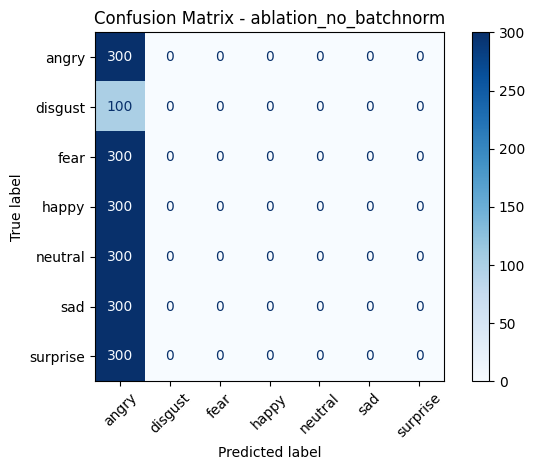

In [ ]:

best_ablation_model = load_model(
    "model_results/ablation_no_batchnorm/ablation_no_batchnorm_best.keras"
)

ablation_best_acc, ablation_best_loss = evaluate_and_save_best_model(
    model=best_ablation_model,
    test_gen=test_generator,
    model_name="ablation_no_batchnorm"
)

The ablation model was trained without Batch Normalization to test how important Batch Normalization was in the deeper CNN. The result dropped heavily to 15.79% test accuracy and 0.04 weighted F1-score.

This shows that Batch Normalization was very important for stable training. Without it, the deeper model could not learn proper class separation and mostly failed to classify the emotions correctly.

Transfer Learning Data Generators

In [ ]:
#  Transfer Learning Data Generators for MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

TL_IMG_SIZE = (96, 96)

tl_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
tl_val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_gen = tl_train_datagen.flow_from_directory(
    augmented_train_dir,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

tl_val_gen = tl_val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

tl_test_gen = tl_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Transfer learning data generators are ready.")
print("Class indices:", tl_train_gen.class_indices)

Found 47999 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Transfer learning data generators are ready.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Build MobileNetV2 Feature Extraction Model

In [ ]:
# Build MobileNetV2 Feature Extraction Model

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze the convolutional base first
base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 362,247 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Train MobileNetV2 Feature Extraction and Save Best

Epoch 1/20


I0000 00:00:1778305100.312225    4517 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_348734__.131
E0000 00:00:1778305119.758527    4517 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 25/750 ━━━━━━━━━━━━━━━━━━━━ 17:58 1s/step - accuracy: 0.1904 - loss: 2.6393

I0000 00:00:1778305170.490983    4517 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_348734__.131
E0000 00:00:1778305179.467628    4517 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3391 - loss: 1.8579

E0000 00:00:1778306349.840310    4517 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 1.48490, saving model to model_results/mobilenetv2_feature_extraction/mobilenetv2_feature_extraction_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1286s 2s/step - accuracy: 0.3838 - loss: 1.6541 - val_accuracy: 0.4312 - val_loss: 1.4849 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.4546 - loss: 1.4358
Epoch 2: val_loss improved from 1.48490 to 1.43661, saving model to model_results/mobilenetv2_feature_extraction/mobilenetv2_feature_extraction_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 454s 595ms/step - accuracy: 0.4563 - loss: 1.4257 - val_accuracy: 0.4549 - val_loss: 1.4366 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4852 - loss: 1.3675
Epoch 3: val_loss did not improve from 1.43661
750/750 ━━━━━━━━━━━━━━━━━━━━ 1123s 1s/step - accuracy: 0.4839 - loss: 1.3626 - val_accuracy: 0.4500 - val_loss: 1.4749 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0

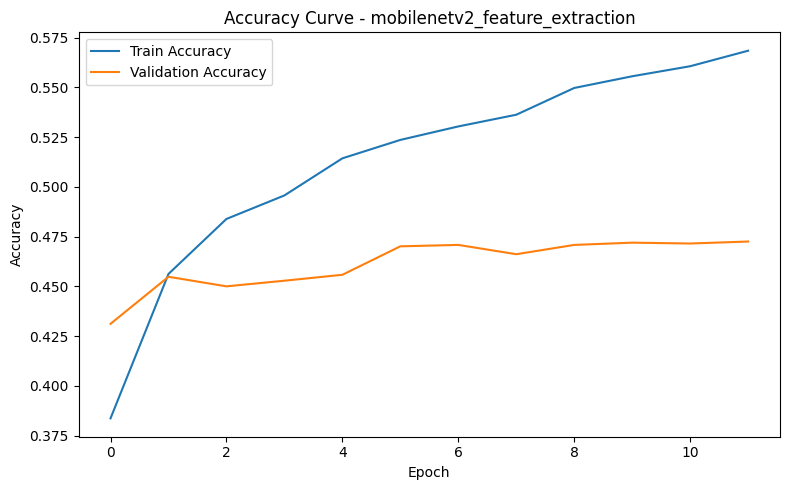

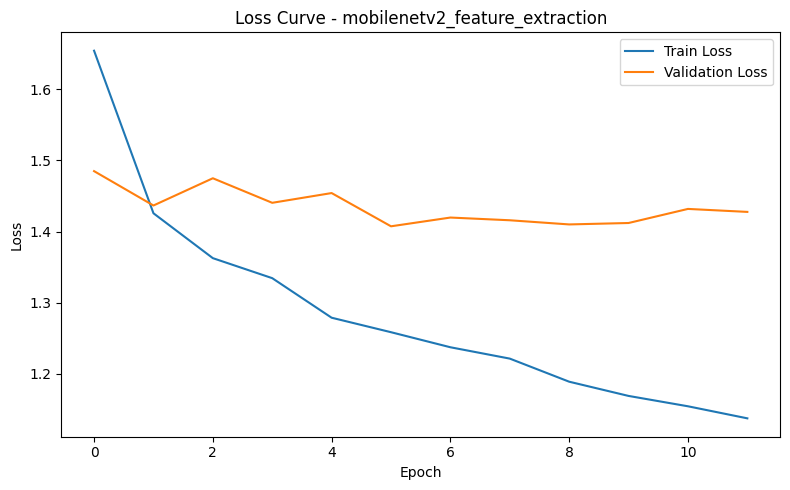

MobileNetV2 feature extraction training time: 7500.28 seconds


In [ ]:
#Train MobileNetV2 Feature Extraction and Save Best Result

start_time = time.time()

mobilenet_feature_history = mobilenet_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,
    callbacks=get_callbacks("mobilenetv2_feature_extraction", patience=6),
    verbose=1
)

mobilenet_feature_time = time.time() - start_time

save_training_history(
    history=mobilenet_feature_history,
    model_name="mobilenetv2_feature_extraction",
    training_time=mobilenet_feature_time
)

plot_and_save_history(
    history=mobilenet_feature_history,
    model_name="mobilenetv2_feature_extraction"
)

print(f"MobileNetV2 feature extraction training time: {mobilenet_feature_time:.2f} seconds")

Load and Evaluate Best MobileNetV2 Feature Extraction Model

Loading best saved model from: model_results/mobilenetv2_feature_extraction/mobilenetv2_feature_extraction_best.keras
29/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3611 - loss: 1.6372

E0000 00:00:1778312734.842693    4518 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


30/30 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.4405 - loss: 1.4769
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 827ms/step

Model: mobilenetv2_feature_extraction
Test Loss: 1.4769
Test Accuracy: 0.4405

Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.29      0.35       300
     disgust       0.55      0.39      0.46       100
        fear       0.37      0.26      0.31       300
       happy       0.49      0.59      0.54       300
     neutral       0.36      0.58      0.45       300
         sad       0.35      0.34      0.34       300
    surprise       0.63      0.60      0.61       300

    accuracy                           0.44      1900
   macro avg       0.45      0.44      0.44      1900
weighted avg       0.44      0.44      0.43      1900



<Figure size 800x600 with 0 Axes>

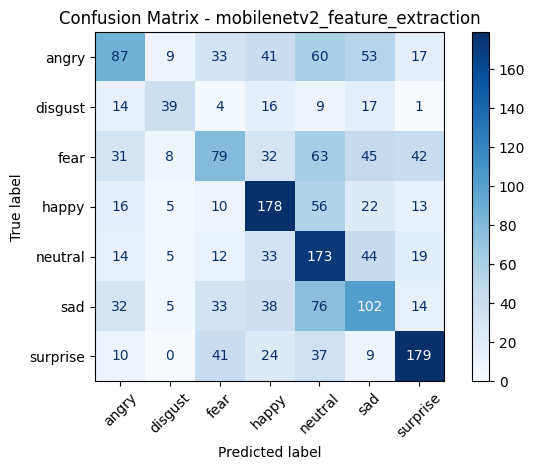

In [ ]:

best_mobilenet_feature_model = load_model(
    "model_results/mobilenetv2_feature_extraction/mobilenetv2_feature_extraction_best.keras"
)

mobilenet_feature_best_acc, mobilenet_feature_best_loss = evaluate_and_save_best_model(
    model=best_mobilenet_feature_model,
    test_gen=tl_test_gen,
    model_name="mobilenetv2_feature_extraction"
)

The MobileNetV2 feature extraction model achieved 44.05% test accuracy and 0.43 weighted F1-score. In this stage, the pretrained convolutional base was frozen, so only the newly added classification layers were trained.

The result was lower than the scratch CNN models. One reason is that MobileNetV2 was pretrained on ImageNet RGB images, while this dataset contains small facial expression images. Because of this difference, the frozen ImageNet features were not fully suitable for this task.

Fine-Tune MobileNetV2 and Save Best

Epoch 1/20


I0000 00:00:1778312871.148953    4520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_420580__.175
E0000 00:00:1778312873.328849    4520 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


458/750 ━━━━━━━━━━━━━━━━━━━━ 5:52 1s/step - accuracy: 0.3659 - loss: 1.7652

I0000 00:00:1778313442.286832    4518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_420580__.175
E0000 00:00:1778313444.708912    4518 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3811 - loss: 1.7123
Epoch 1: val_loss improved from None to 1.45028, saving model to model_results/mobilenetv2_finetuned/mobilenetv2_finetuned_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 1100s 1s/step - accuracy: 0.4140 - loss: 1.6027 - val_accuracy: 0.4669 - val_loss: 1.4503 - learning_rate: 1.0000e-05
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.4726 - loss: 1.3941
Epoch 2: val_loss improved from 1.45028 to 1.40859, saving model to model_results/mobilenetv2_finetuned/mobilenetv2_finetuned_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.4783 - loss: 1.3753 - val_accuracy: 0.4728 - val_loss: 1.4086 - learning_rate: 1.0000e-05
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.5061 - loss: 1.3041
Epoch 3: val_loss improved from 1.40859 to 1.39003, saving model to model_results/mobilenetv2_finetuned/mobilenetv2_finetuned_best.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 501s 668ms/step - ac

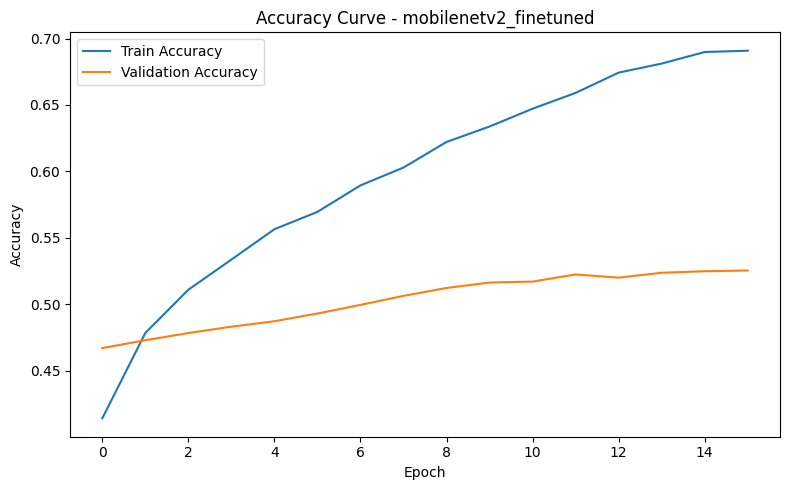

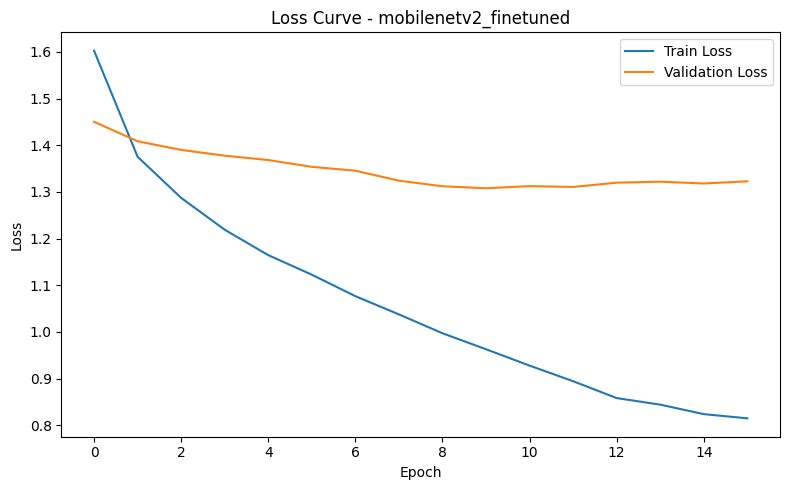

MobileNetV2 fine-tuning training time: 7732.33 seconds


In [ ]:

# from the trained MobileNetV2 model
base_model.trainable = True

# Freeze most layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

mobilenet_finetune_history = mobilenet_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,
    callbacks=get_callbacks("mobilenetv2_finetuned", patience=6),
    verbose=1
)

mobilenet_finetune_time = time.time() - start_time

save_training_history(
    history=mobilenet_finetune_history,
    model_name="mobilenetv2_finetuned",
    training_time=mobilenet_finetune_time
)

plot_and_save_history(
    history=mobilenet_finetune_history,
    model_name="mobilenetv2_finetuned"
)

print(f"MobileNetV2 fine-tuning training time: {mobilenet_finetune_time:.2f} seconds")

Load and Evaluate Best Fine-Tuned MobileNetV2

Loading best saved model from: model_results/mobilenetv2_finetuned/mobilenetv2_finetuned_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 943ms/step - accuracy: 0.5026 - loss: 1.3731
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 795ms/step

Model: mobilenetv2_finetuned
Test Loss: 1.3731
Test Accuracy: 0.5026

Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.44      0.45       300
     disgust       0.62      0.51      0.56       100
        fear       0.41      0.27      0.32       300
       happy       0.58      0.69      0.63       300
     neutral       0.45      0.56      0.50       300
         sad       0.38      0.36      0.37       300
    surprise       0.66      0.70      0.68       300

    accuracy                           0.50      1900
   macro avg       0.51      0.50      0.50      1900
weighted avg       0.50      0.50      0.49      1900



<Figure size 800x600 with 0 Axes>

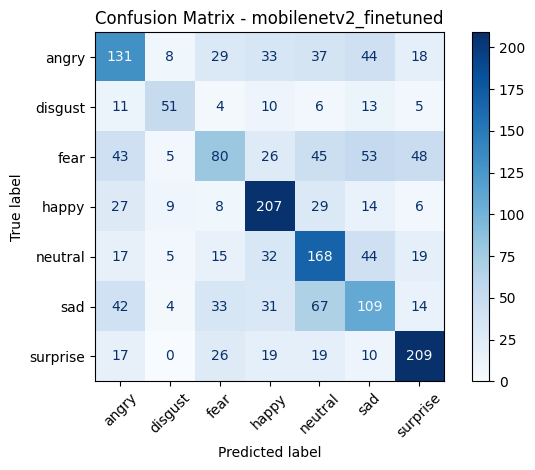

In [ ]:
# Load and Evaluate Best Fine-Tuned MobileNetV2 Model

best_mobilenet_finetuned_model = load_model(
    "model_results/mobilenetv2_finetuned/mobilenetv2_finetuned_best.keras"
)

mobilenet_finetuned_best_acc, mobilenet_finetuned_best_loss = evaluate_and_save_best_model(
    model=best_mobilenet_finetuned_model,
    test_gen=tl_test_gen,
    model_name="mobilenetv2_finetuned"
)

After fine-tuning MobileNetV2, the performance improved to 50.26% test accuracy and 0.49 weighted F1-score. This shows that unfreezing some layers helped the pretrained model adapt better to the facial expression dataset.

However, the fine-tuned MobileNetV2 still did not outperform the deeper CNN trained from scratch. This may be because the dataset images are small facial images, while MobileNetV2 is designed for larger RGB natural images.

Sample Prediction Function

In [ ]:
# Function to Show 4 Sample Predictions from Each Class

from tensorflow.keras.utils import load_img, img_to_array

def show_predictions_per_class(model, test_gen, model_name, samples_per_class=4, color_mode="grayscale"):
    """
    Shows sample predictions by selecting a fixed number of images from each class.
    This avoids showing mostly one class from the first batch.
    """

    class_labels = list(test_gen.class_indices.keys())
    filepaths = np.array(test_gen.filepaths)
    true_classes = np.array(test_gen.classes)

    total_classes = len(class_labels)

    plt.figure(figsize=(samples_per_class * 3, total_classes * 3))

    plot_index = 1

    for class_idx, class_name in enumerate(class_labels):
        class_indices = np.where(true_classes == class_idx)[0]

        selected_indices = np.random.choice(
            class_indices,
            size=min(samples_per_class, len(class_indices)),
            replace=False
        )

        for idx in selected_indices:
            img_path = filepaths[idx]

            # Load image according to generator type
            if color_mode == "grayscale":
                img = load_img(
                    img_path,
                    target_size=test_gen.target_size,
                    color_mode="grayscale"
                )
            else:
                img = load_img(
                    img_path,
                    target_size=test_gen.target_size,
                    color_mode="rgb"
                )

            img_array = img_to_array(img)

            # Apply the same preprocessing used by the generator
            img_array_processed = test_gen.image_data_generator.standardize(img_array.copy())

            input_img = np.expand_dims(img_array_processed, axis=0)

            prediction = model.predict(input_img, verbose=0)
            pred_idx = np.argmax(prediction, axis=1)[0]
            pred_label = class_labels[pred_idx]

            plt.subplot(total_classes, samples_per_class, plot_index)

            # Display image cleanly
            if color_mode == "grayscale":
                plt.imshow(img_array.squeeze(), cmap="gray")
            else:
                display_img = img_array.astype("uint8")
                plt.imshow(display_img)

            title_color = "green" if pred_label == class_name else "red"
            plt.title(
                f"True: {class_name}\nPred: {pred_label}",
                color=title_color,
                fontsize=9
            )
            plt.axis("off")

            plot_index += 1

    plt.suptitle(f"Sample Predictions Per Class - {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

Show Sample Predictions for Best Scratch Model

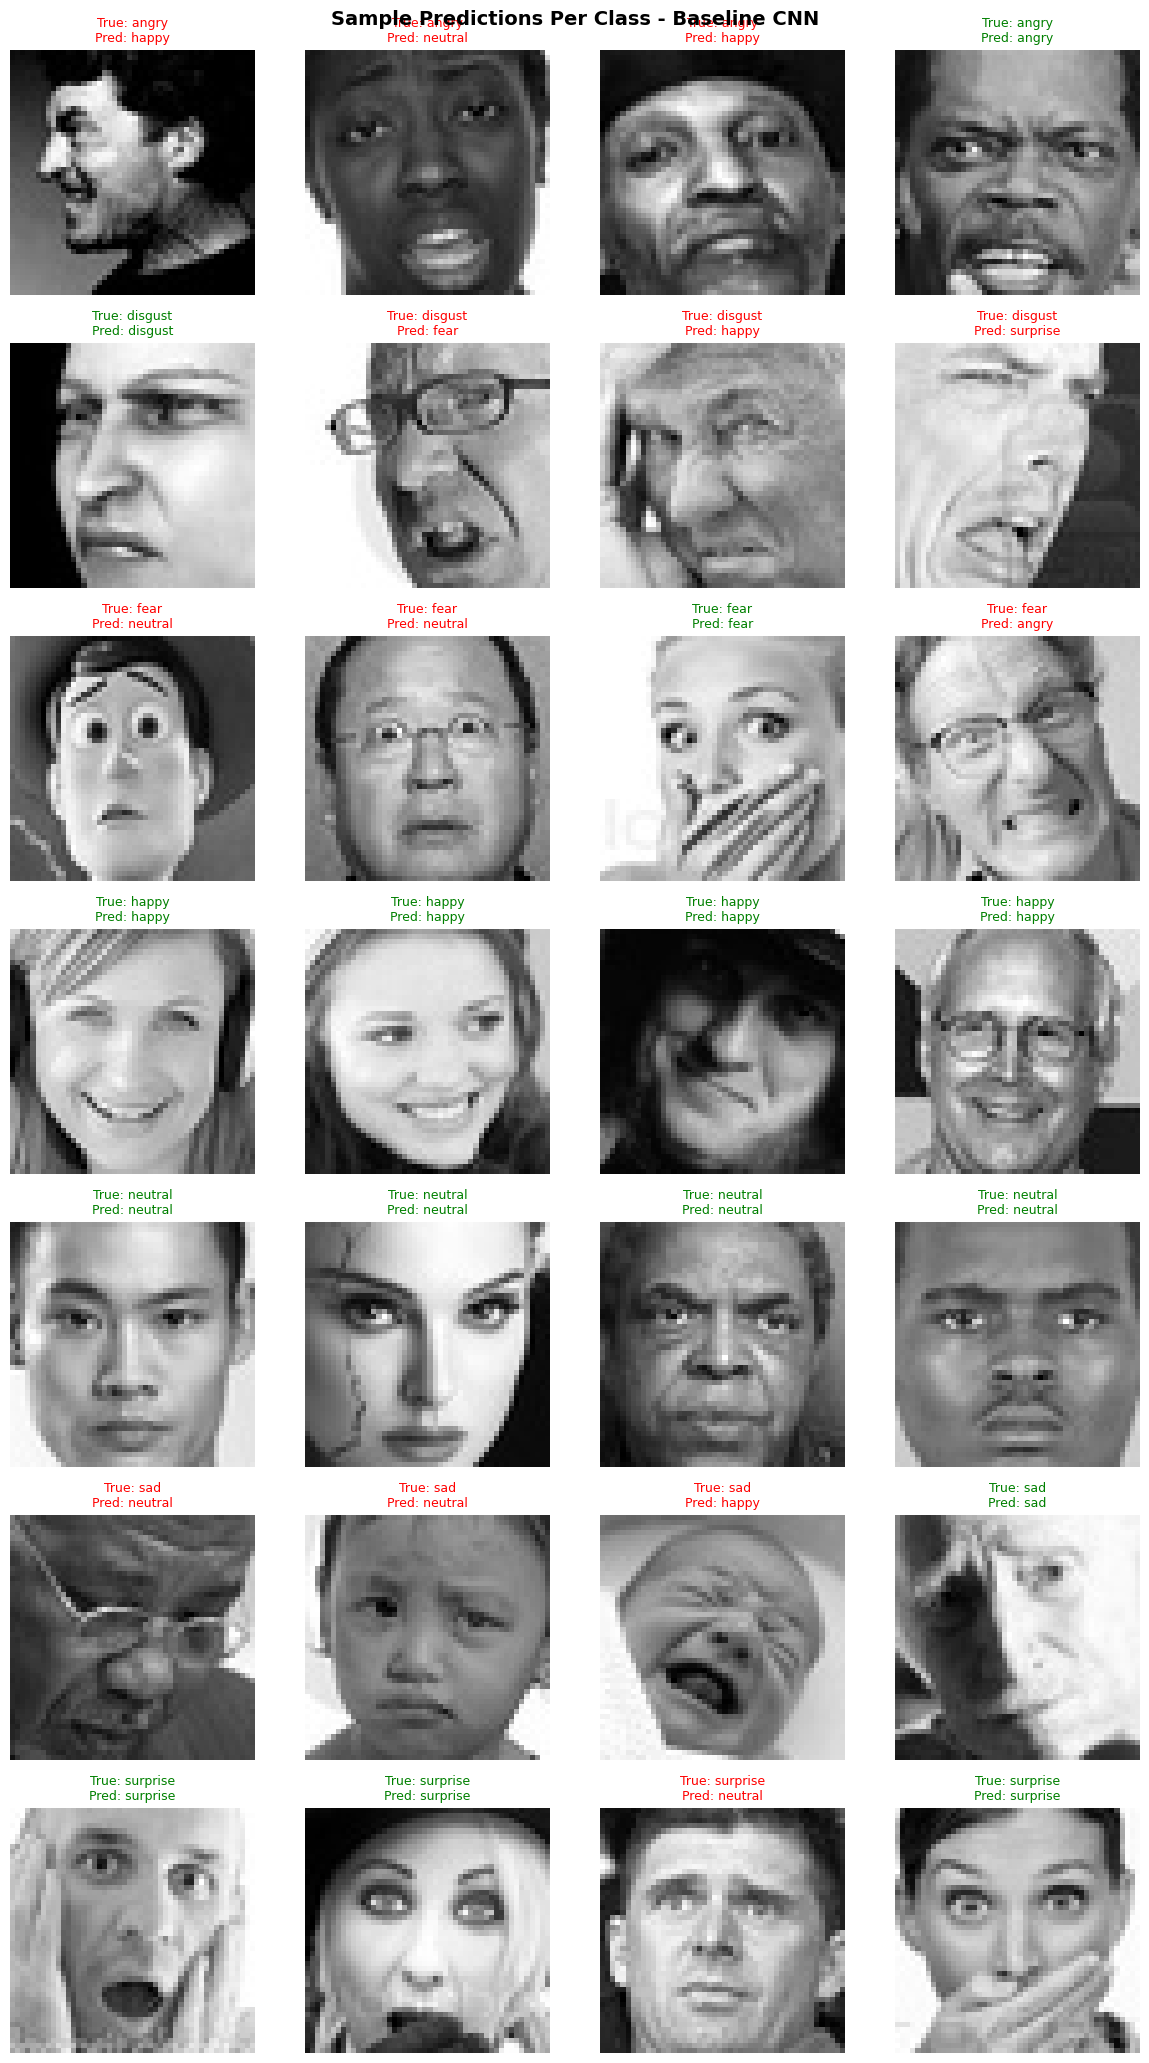

In [ ]:
best_baseline_model = load_model("model_results/baseline_cnn/baseline_cnn_best.keras")
# Sample Predictions Per Class for Baseline CNN Model

show_predictions_per_class(
    model=best_baseline_model,
    test_gen=test_generator,
    model_name="Baseline CNN",
    samples_per_class=4,
    color_mode="grayscale"
)

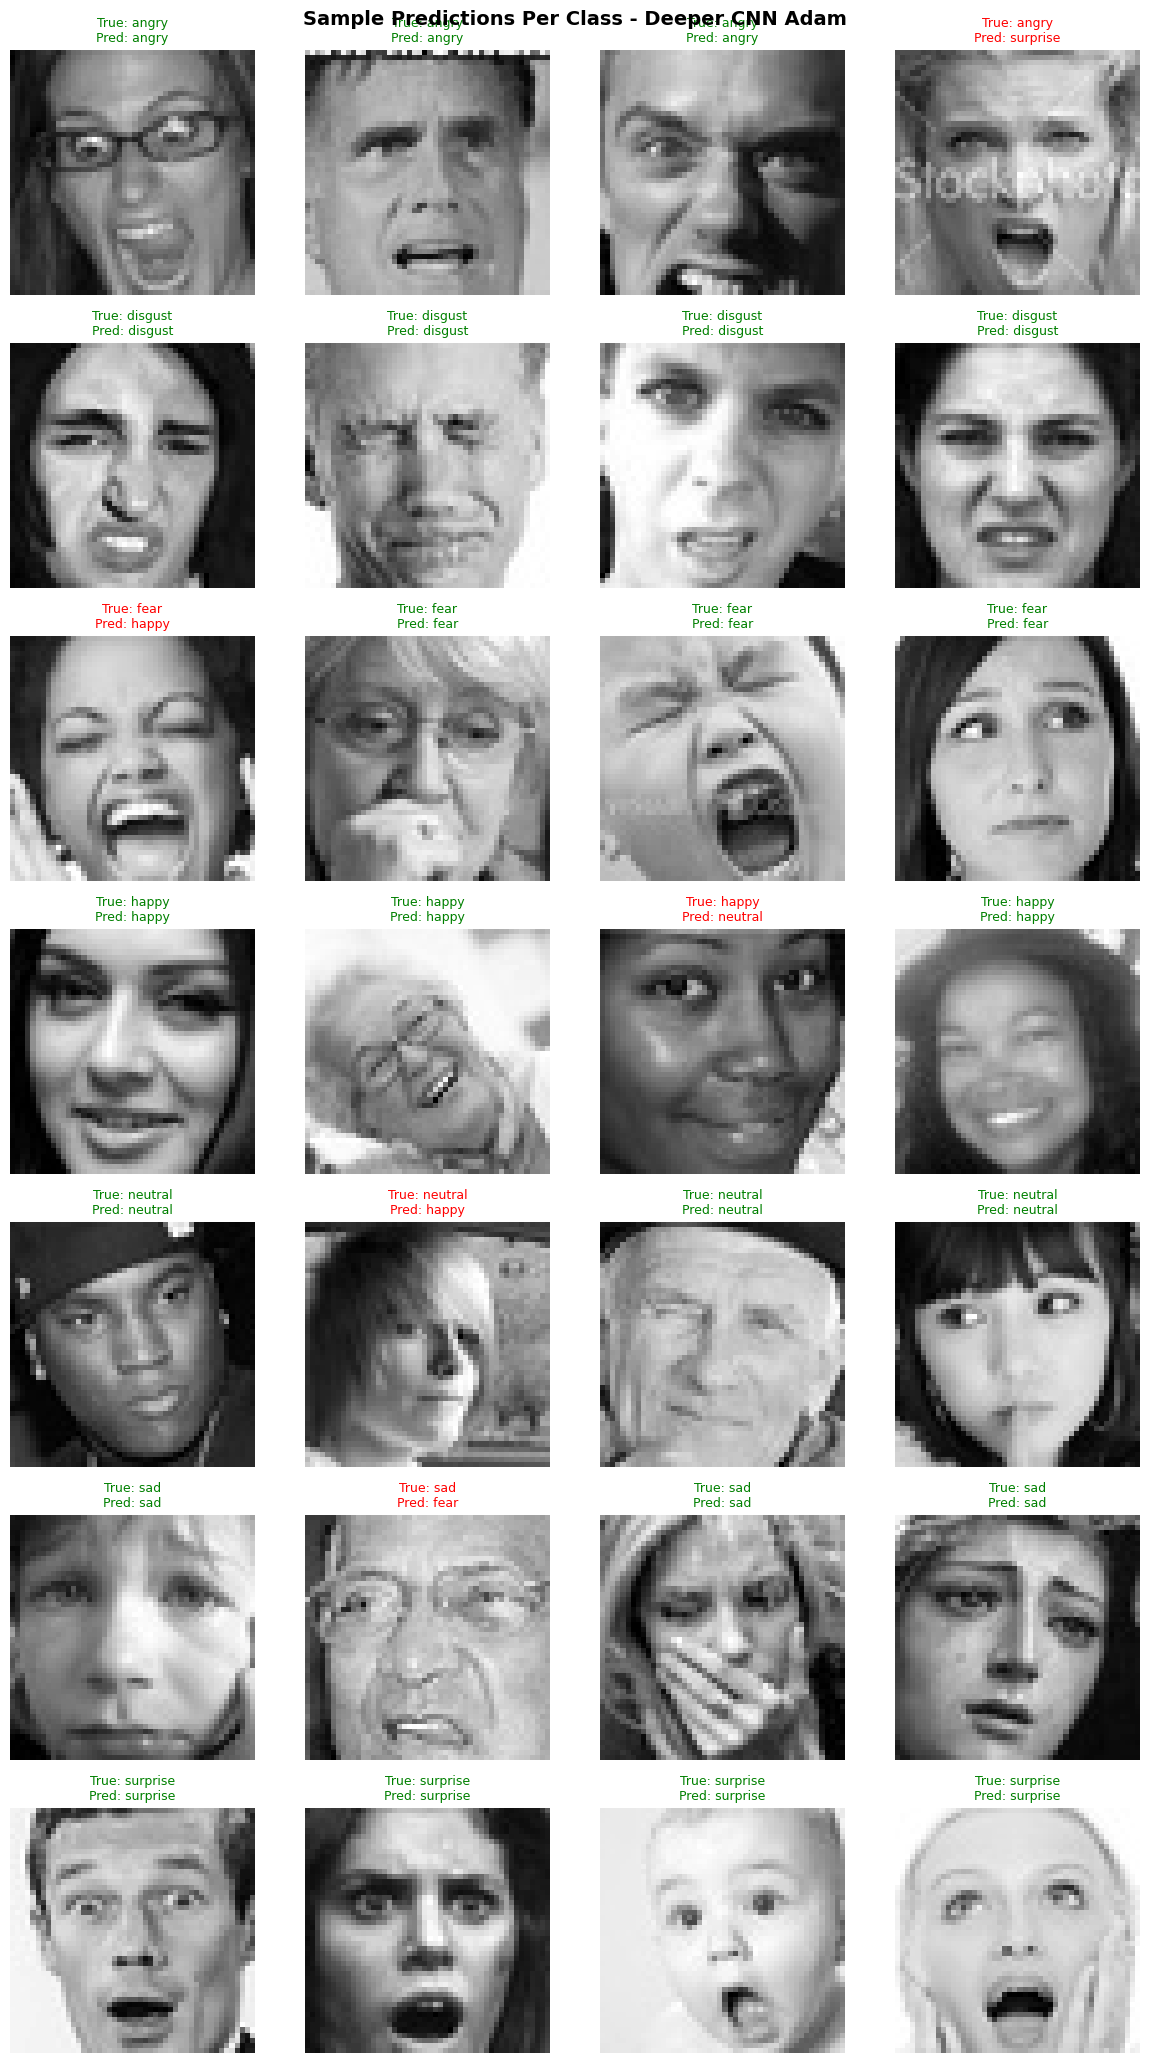

In [ ]:
# Sample Predictions Per Class for Best Deeper CNN Adam Model

show_predictions_per_class(
    model=best_deeper_adam_model,
    test_gen=test_generator,
    model_name="Deeper CNN Adam",
    samples_per_class=4,
    color_mode="grayscale"
)

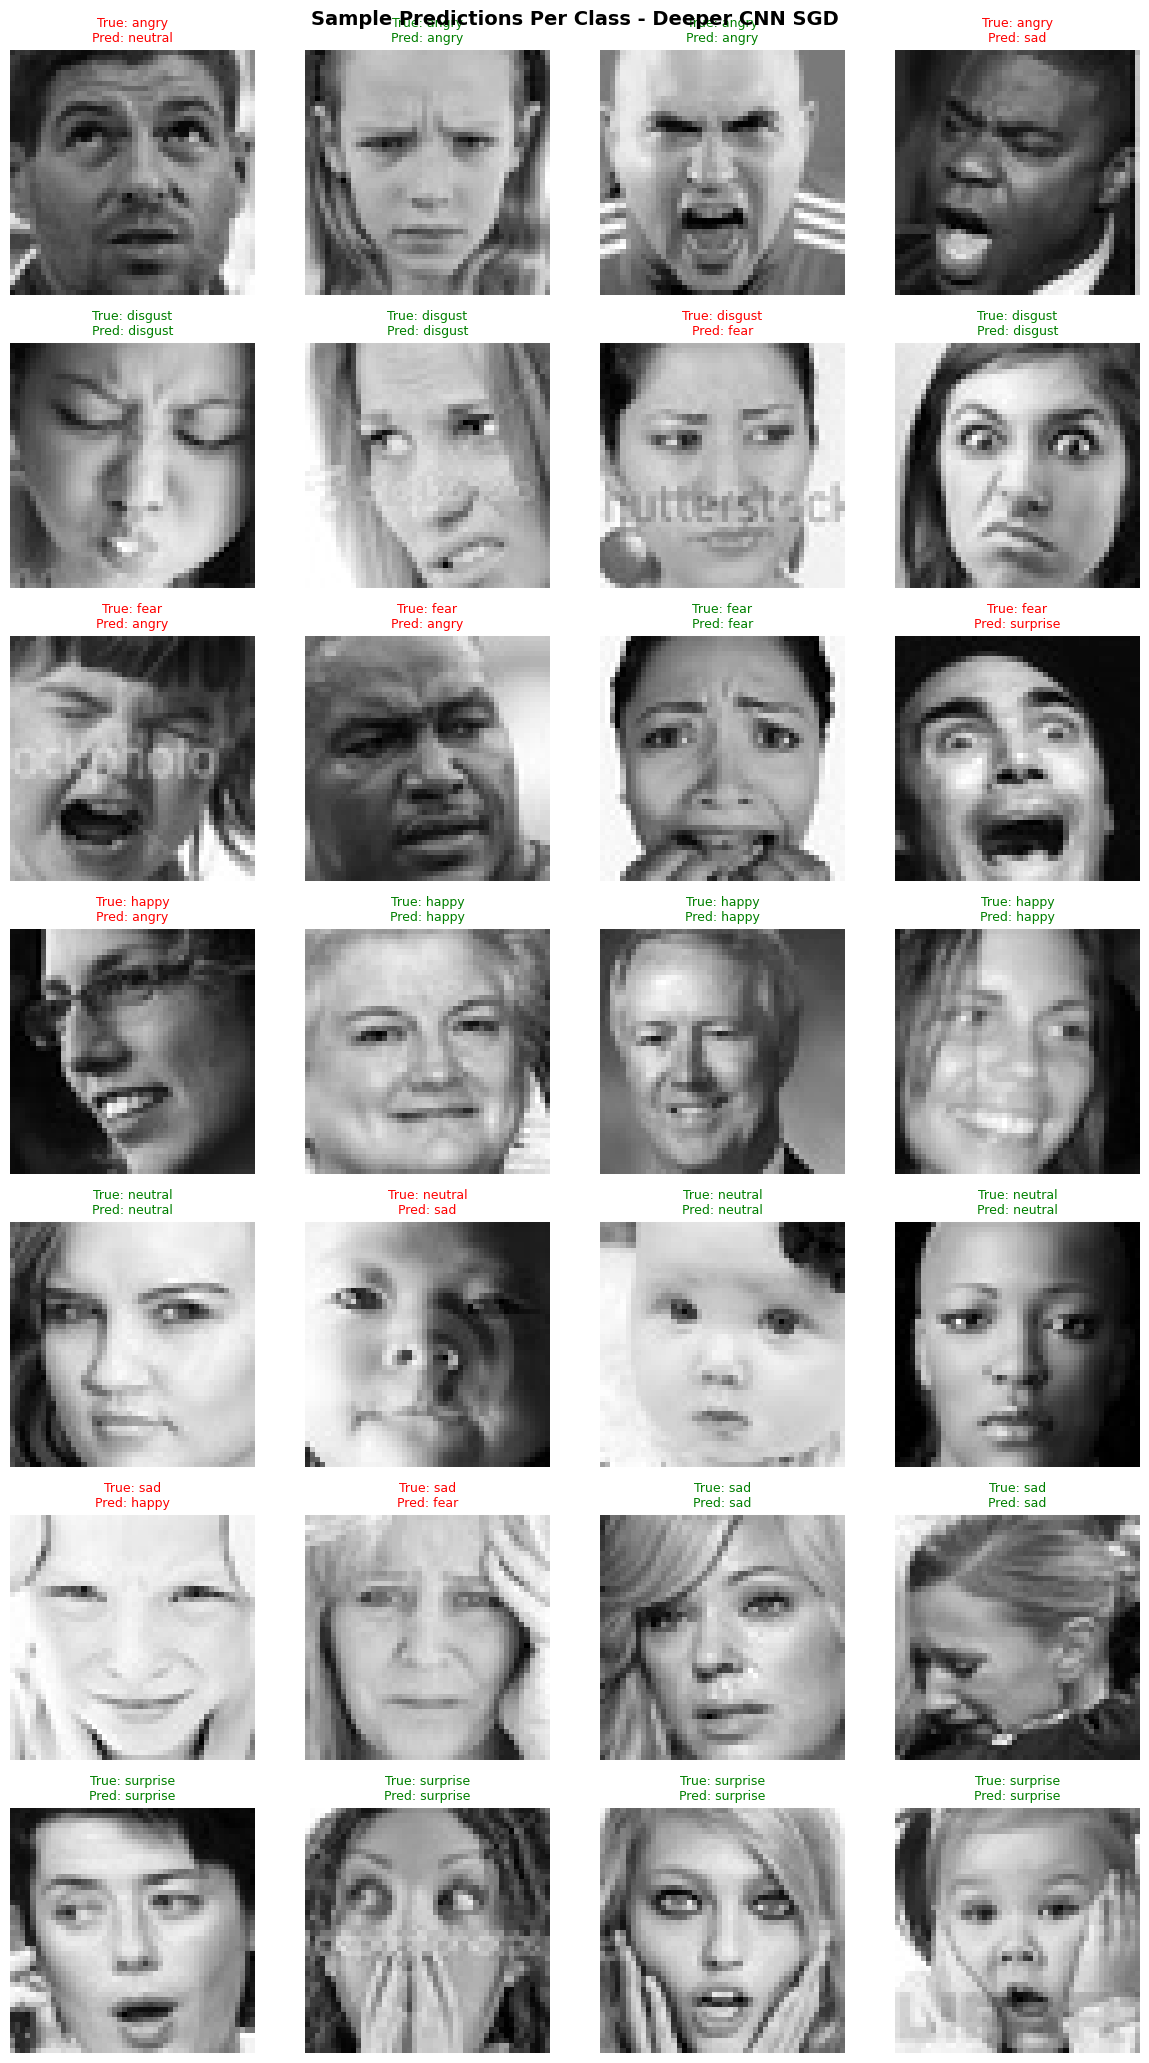

In [ ]:
# Sample Predictions Per Class for Best Deeper CNN SGD Model
best_sgd_model = load_model("model_results/deeper_cnn_sgd/deeper_cnn_sgd_best.keras")

show_predictions_per_class(
    model=best_sgd_model,
    test_gen=test_generator,
    model_name="Deeper CNN SGD",
    samples_per_class=4,
    color_mode="grayscale"
)

Show Sample Predictions for MobileNetV2

E0000 00:00:1778323415.361280    4517 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


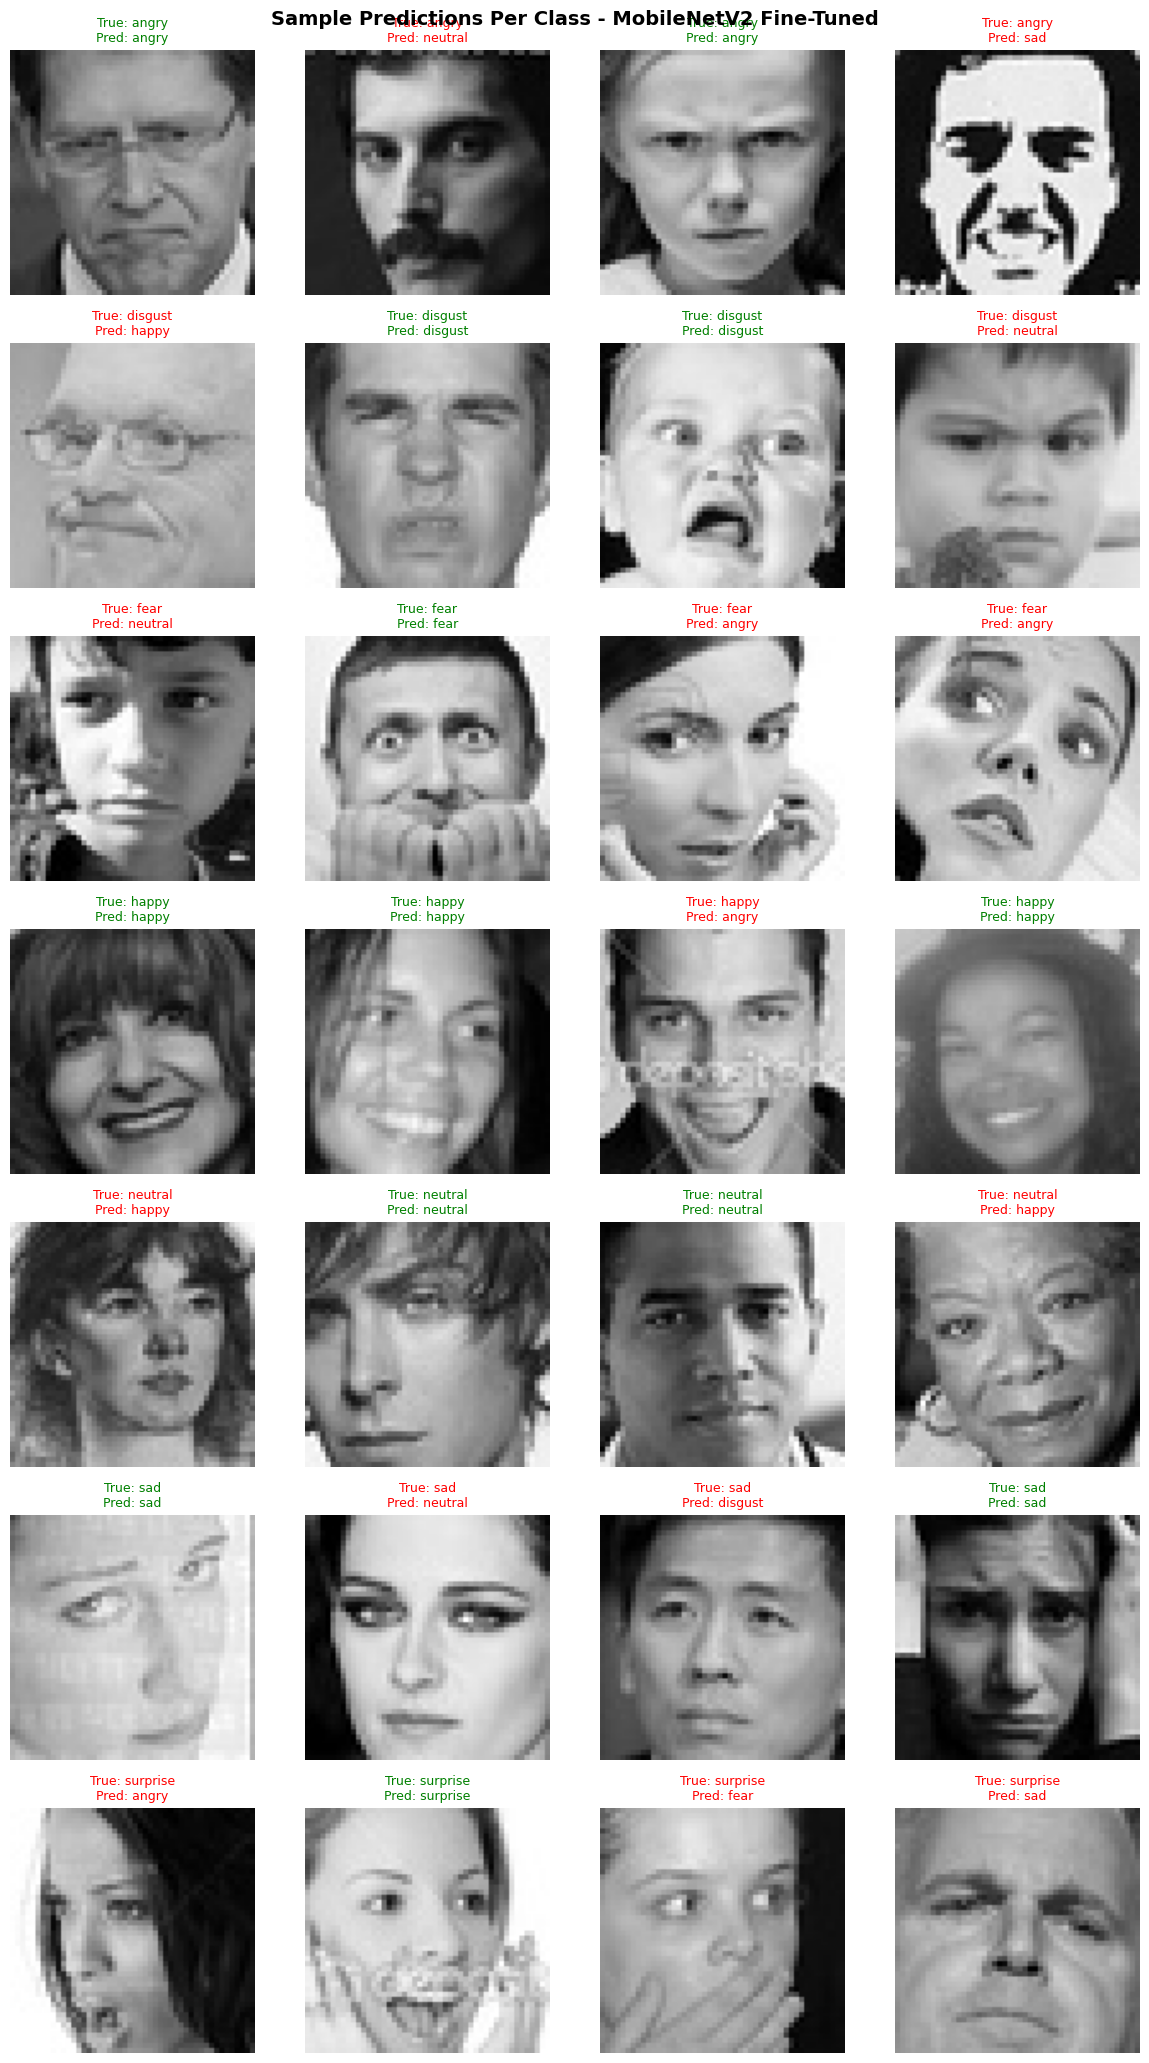

In [ ]:

show_predictions_per_class(
    model=best_mobilenet_finetuned_model,
    test_gen=tl_test_gen,
    model_name="MobileNetV2 Fine-Tuned",
    samples_per_class=4,
    color_mode="rgb"
)

Final Best Model Comparison

,Model,Best Test Accuracy,Best Test Loss,Training Time Seconds
0,Deeper CNN SGD,0.614737,1.111474,15083.446344
1,Deeper CNN Adam,0.587368,1.102208,7930.972922
2,Baseline CNN,0.531053,1.302935,10267.344776
3,MobileNetV2 Fine-Tuned,0.502632,1.373080,7732.330489
4,MobileNetV2 Feature Extraction,0.440526,1.476887,7500.276254
5,Ablation No BatchNorm,0.157895,1.944641,4262.993770


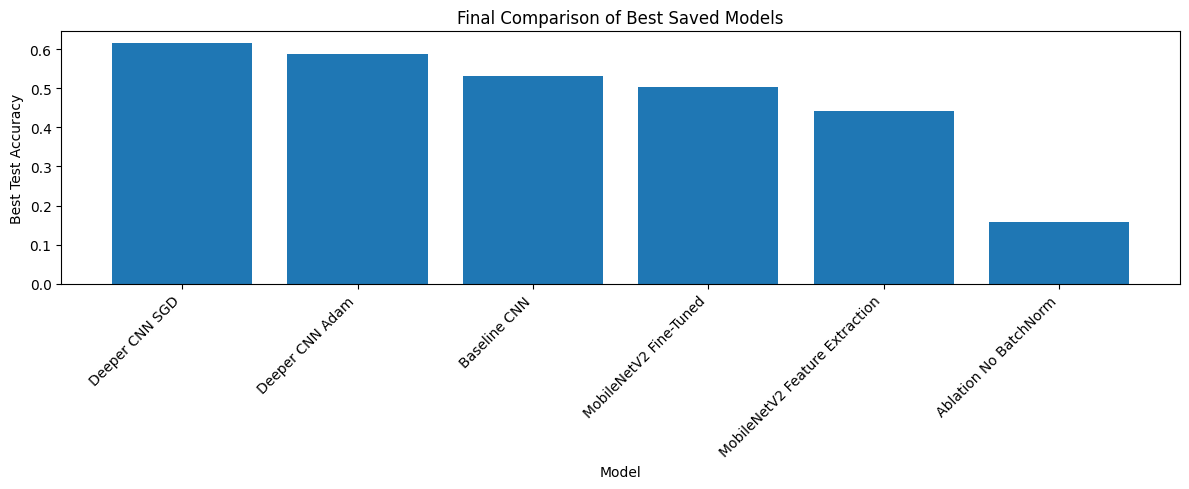

Best Overall Model: Deeper CNN SGD
Best Test Accuracy: 0.6147


In [ ]:
# Cell 34: Final Comparison of All Best Saved Models

final_results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN Adam",
        "Deeper CNN SGD",
        "Ablation No BatchNorm",
        "MobileNetV2 Feature Extraction",
        "MobileNetV2 Fine-Tuned"
    ],
    "Best Test Accuracy": [
        baseline_best_acc,
        deeper_adam_best_acc,
        sgd_best_acc,
        ablation_best_acc,
        mobilenet_feature_best_acc,
        mobilenet_finetuned_best_acc
    ],
    "Best Test Loss": [
        baseline_best_loss,
        deeper_adam_best_loss,
        sgd_best_loss,
        ablation_best_loss,
        mobilenet_feature_best_loss,
        mobilenet_finetuned_best_loss
    ],
    "Training Time Seconds": [
        baseline_train_time,
        deeper_train_time,
        sgd_train_time,
        ablation_train_time,
        mobilenet_feature_time,
        mobilenet_finetune_time
    ]
})

final_results = final_results.sort_values(
    by="Best Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_results)

final_results.to_csv(
    os.path.join(RESULTS_DIR, "final_best_model_comparison.csv"),
    index=False
)

plt.figure(figsize=(12, 5))
plt.bar(final_results["Model"], final_results["Best Test Accuracy"])
plt.title("Final Comparison of Best Saved Models")
plt.xlabel("Model")
plt.ylabel("Best Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "final_best_model_comparison.png"),
    dpi=300
)
plt.show()

best_model_name = final_results.loc[0, "Model"]
best_model_acc = final_results.loc[0, "Best Test Accuracy"]

print(f"Best Overall Model: {best_model_name}")
print(f"Best Test Accuracy: {best_model_acc:.4f}")

The final comparison shows that the Deeper CNN with SGD is the best-performing model. It achieved the highest test accuracy of 61.47% and the highest weighted F1-score of 0.61. The baseline CNN performed lower, which shows that a simple architecture was not enough for this dataset.

The Adam version of the deeper CNN improved over the baseline, but SGD gave better final generalisation. The ablation study proved that Batch Normalization was important because removing it caused a large performance drop. Transfer learning with MobileNetV2 improved after fine-tuning, but it did not perform better than the custom CNN models.

Overall, the final selected model is the Deeper CNN with SGD because it gives the strongest balance between accuracy and weighted F1-score.